In [1]:
# Core libraries used throughout the assignment
!pip install -q numpy pandas matplotlib pillow scikit-image scikit-learn torch torchvision requests


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import os
import json
import glob
import base64
import zipfile
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, measure
from skimage.measure import regionprops_table
import json
import requests

from pathlib import Path
from PIL import Image

from skimage import io, color, transform, exposure

In [3]:
ZIP_PATH = "nuclei_dataset.zip"
EXTRACT_DIR = "assignment_dataset"

print("ZIP exists:", os.path.exists(ZIP_PATH))

ZIP exists: True


In [4]:
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)

Dataset extracted to: assignment_dataset


In [5]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    # only show first few filenames to avoid huge output
    for file in files[:5]:
        print(f"{indent}    {file}")

assignment_dataset/
    nuclei_dataset/
        dataset_summary.json
        make_dataset.py
        metadata.csv
        README.md
        test/
            images/
                test_000.png
                test_001.png
                test_002.png
                test_003.png
                test_004.png
            labels/
                test_000.png
                test_001.png
                test_002.png
                test_003.png
                test_004.png
            masks/
                test_000.png
                test_001.png
                test_002.png
                test_003.png
                test_004.png
        test_corrupted/
            images/
                test_000_blur.png
                test_000_lowcontrast.png
                test_004_blur.png
                test_004_lowcontrast.png
        train/
            images/
                train_000.png
                train_001.png
                train_002.png
                train_003.png
           

In [6]:
DATA_ROOT = Path(EXTRACT_DIR) / "nuclei_dataset"

TRAIN_IMG_DIR = DATA_ROOT / "train" / "images"
TRAIN_MASK_DIR = DATA_ROOT / "train" / "masks"

VAL_IMG_DIR = DATA_ROOT / "val" / "images"
VAL_MASK_DIR = DATA_ROOT / "val" / "masks"

TEST_IMG_DIR = DATA_ROOT / "test" / "images"
TEST_MASK_DIR = DATA_ROOT / "test" / "masks"

print("Training images:", TRAIN_IMG_DIR)
print("Validation images:", VAL_IMG_DIR)
print("Test images:", TEST_IMG_DIR)

Training images: assignment_dataset\nuclei_dataset\train\images
Validation images: assignment_dataset\nuclei_dataset\val\images
Test images: assignment_dataset\nuclei_dataset\test\images


In [7]:
def count_png(folder):
    return len(list(Path(folder).glob("*.png")))


print("Number of training images :", count_png(TRAIN_IMG_DIR))
print("Number of validation images:", count_png(VAL_IMG_DIR))
print("Number of test images      :", count_png(TEST_IMG_DIR))

Number of training images : 80
Number of validation images: 20
Number of test images      : 12


In [8]:
metadata_path = DATA_ROOT / "metadata.csv"

metadata = pd.read_csv(metadata_path)

print("Metadata shape:", metadata.shape)
display(metadata.head())

Metadata shape: (112, 7)


,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


In [9]:
summary_path = DATA_ROOT / "dataset_summary.json"

with open(summary_path, "r") as f:
    dataset_summary = json.load(f)

print(json.dumps(dataset_summary, indent=2))

{
  "images_total": 112,
  "splits": {
    "train": 80,
    "val": 20,
    "test": 12
  },
  "image_size": [
    256,
    256
  ],
  "channels": 3,
  "mask_encoding": "binary png (0/255); instance labels in /labels (16-bit)"
}


In [10]:
train_image_paths = sorted(TRAIN_IMG_DIR.glob("*.png"))
val_image_paths = sorted(VAL_IMG_DIR.glob("*.png"))
test_image_paths = sorted(TEST_IMG_DIR.glob("*.png"))

print("Example training image:")
print(train_image_paths[0])

Example training image:
assignment_dataset\nuclei_dataset\train\images\train_000.png


In [11]:
sample_path = train_image_paths[0]

sample_image = io.imread(sample_path)

print("Filename :", sample_path.name)
print("Shape    :", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Minimum  :", sample_image.min())
print("Maximum  :", sample_image.max())

Filename : train_000.png
Shape    : (256, 256, 3)
Data type: uint8
Minimum  : 0
Maximum  : 255


In [12]:
def preprocess_image(image_path, output_size=(256, 256)):
    """
    Load an image, convert it to grayscale,
    resize it to 256x256, and return float32 [0,1].
    """

    image = io.imread(image_path)

    # Convert RGB/RGBA to grayscale
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)

        image = color.rgb2gray(image)

    # Resize
    image = transform.resize(
        image,
        output_size,
        preserve_range=False,
        anti_aliasing=True
    )

    return image.astype(np.float32)

In [13]:
original = io.imread(train_image_paths[0])
processed = preprocess_image(train_image_paths[0])

print("Original shape :", original.shape)
print("Processed shape:", processed.shape)
print("Processed range:", processed.min(), "to", processed.max())

Original shape : (256, 256, 3)
Processed shape: (256, 256)
Processed range: 0.0 to 0.34678861


In [14]:
PREPROCESSED_ROOT = Path("preprocessed")

PREP_TRAIN = PREPROCESSED_ROOT / "train"
PREP_VAL = PREPROCESSED_ROOT / "val"
PREP_TEST = PREPROCESSED_ROOT / "test"

for folder in [PREP_TRAIN, PREP_VAL, PREP_TEST]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created.")

Folders created.


In [15]:
def preprocess_and_save(input_paths, output_folder):

    for path in input_paths:

        processed = preprocess_image(path)

        output_path = output_folder / path.name

        # Convert from [0,1] float to uint8 for saving
        image_uint8 = (processed * 255).astype(np.uint8)

        io.imsave(output_path, image_uint8)

    print(f"Saved {len(input_paths)} images to {output_folder}")


preprocess_and_save(train_image_paths, PREP_TRAIN)
preprocess_and_save(val_image_paths, PREP_VAL)
preprocess_and_save(test_image_paths, PREP_TEST)

Saved 80 images to preprocessed\train
Saved 20 images to preprocessed\val
Saved 12 images to preprocessed\test


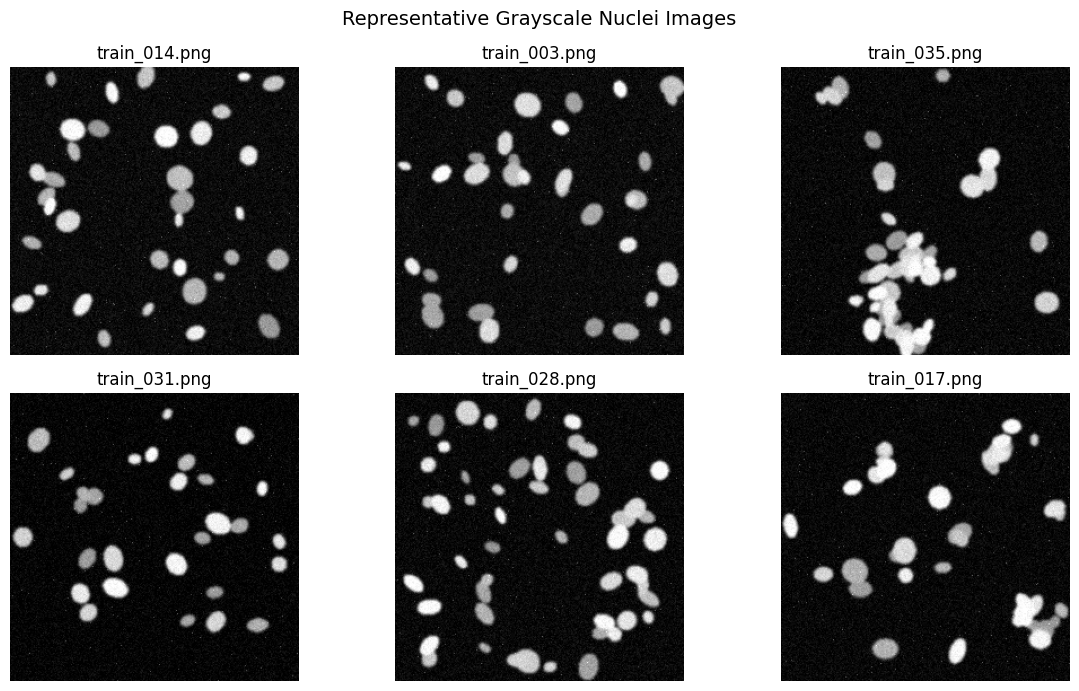

In [16]:
random.seed(42)

sample_paths = random.sample(train_image_paths, 6)

plt.figure(figsize=(12, 7))

for i, path in enumerate(sample_paths):

    image = preprocess_image(path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(path.name)

    plt.axis("off")

plt.suptitle("Representative Grayscale Nuclei Images", fontsize=14)

plt.tight_layout()

plt.savefig(
    "task1_sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

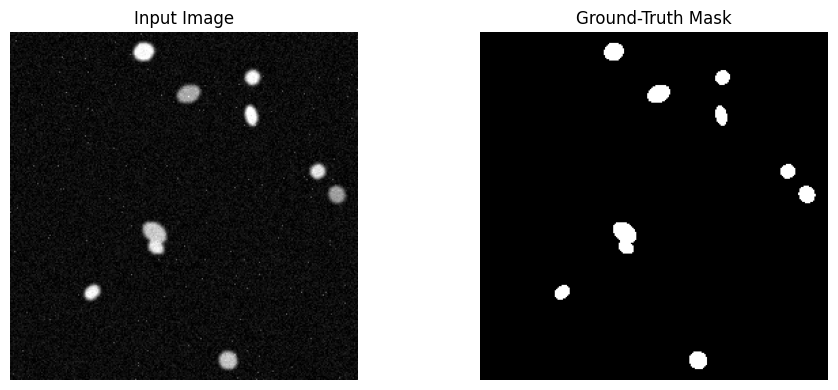

In [17]:
example_name = train_image_paths[0].name

image_path = TRAIN_IMG_DIR / example_name
mask_path = TRAIN_MASK_DIR / example_name

image = preprocess_image(image_path)
mask = io.imread(mask_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground-Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
all_pixels = []

for path in train_image_paths:
    image = preprocess_image(path)

    all_pixels.append(image.flatten())

all_pixels = np.concatenate(all_pixels)

print("Total pixels analysed:", len(all_pixels))
print("Mean intensity:", all_pixels.mean())
print("Std intensity :", all_pixels.std())
print("Min intensity :", all_pixels.min())
print("Max intensity :", all_pixels.max())

Total pixels analysed: 5242880
Mean intensity: 0.035951998
Std intensity : 0.070193864
Min intensity : 0.0
Max intensity : 0.34678861


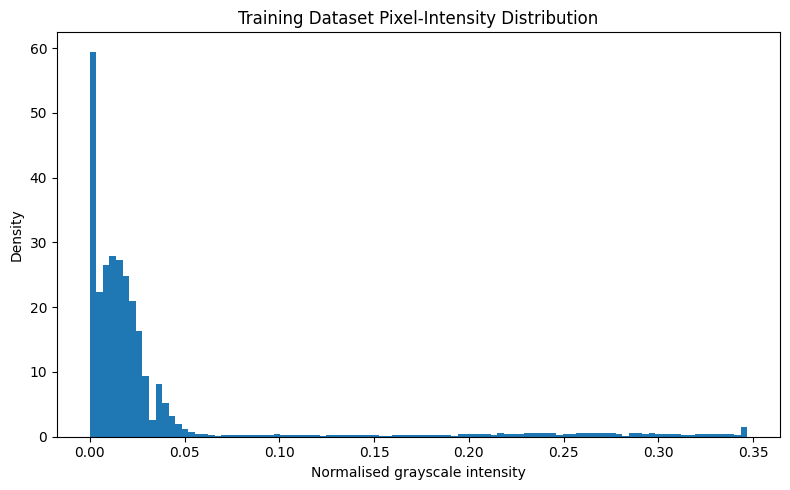

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    all_pixels,
    bins=100,
    density=True
)

plt.xlabel("Normalised grayscale intensity")
plt.ylabel("Density")
plt.title("Training Dataset Pixel-Intensity Distribution")

plt.tight_layout()

plt.savefig(
    "task1_global_intensity_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

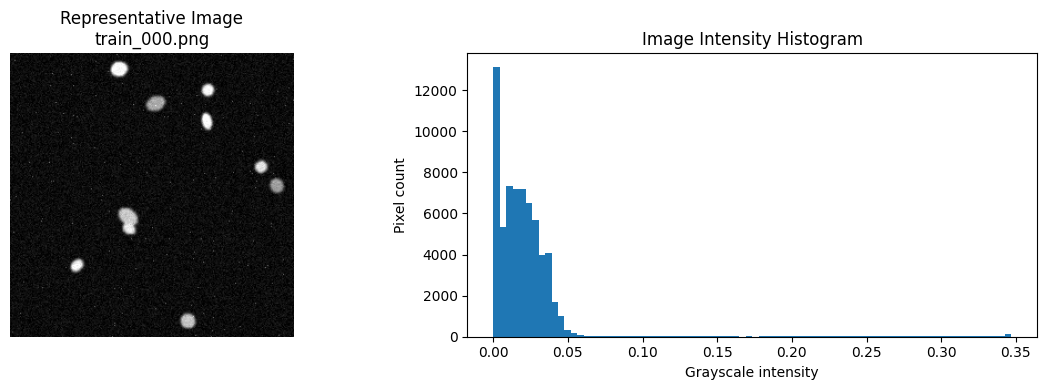

In [20]:
representative_path = train_image_paths[0]

representative_image = preprocess_image(representative_path)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.imshow(representative_image, cmap="gray")

plt.title(f"Representative Image\n{representative_path.name}")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.hist(
    representative_image.ravel(),
    bins=80
)

plt.xlabel("Grayscale intensity")
plt.ylabel("Pixel count")

plt.title("Image Intensity Histogram")

plt.tight_layout()

plt.savefig(
    "task1_representative_image_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
image_statistics = []

for path in train_image_paths:

    img = preprocess_image(path)

    image_statistics.append({
        "image_id": path.stem,
        "mean_intensity": img.mean(),
        "std_intensity": img.std(),
        "min_intensity": img.min(),
        "max_intensity": img.max()
    })

eda_df = pd.DataFrame(image_statistics)

display(eda_df.head())

,image_id,mean_intensity,std_intensity,min_intensity,max_intensity
0,train_000,0.023034,0.037153,0.0,0.346789
1,train_001,0.035815,0.071550,0.0,0.346789
2,train_002,0.019912,0.049343,0.0,0.346789
3,train_003,0.043008,0.073069,0.0,0.346789
4,train_004,0.070398,0.103652,0.0,0.346789


In [22]:
display(eda_df.describe())

,mean_intensity,std_intensity,min_intensity,max_intensity
count,80.000000,80.000000,80.0,80.000000
mean,0.035952,0.066472,0.0,0.346789
std,0.013454,0.018278,0.0,0.000000
min,0.014211,0.032194,0.0,0.346789
25%,0.024504,0.053477,0.0,0.346789
50%,0.035850,0.069180,0.0,0.346789
75%,0.042268,0.077791,0.0,0.346789
max,0.072555,0.103652,0.0,0.346789


In [23]:
eda_df.to_csv("task1_eda_statistics.csv", index=False)

print("Saved: task1_eda_statistics.csv")

Saved: task1_eda_statistics.csv


In [24]:
dataset_mean = eda_df["mean_intensity"].mean()

eda_df["distance_from_global_mean"] = abs(
    eda_df["mean_intensity"] - dataset_mean
)

representative_row = (
    eda_df
    .sort_values("distance_from_global_mean")
    .iloc[0]
)

representative_name = representative_row["image_id"] + ".png"

representative_path = TRAIN_IMG_DIR / representative_name

print("Dataset global mean intensity:", dataset_mean)

print("Representative image:", representative_name)

print(
    "Representative image mean:",
    representative_row["mean_intensity"]
)

Dataset global mean intensity: 0.035951998
Representative image: train_033.png
Representative image mean: 0.03598933


In [25]:
rep_img = preprocess_image(representative_path)

rep_img_uint8 = (rep_img * 255).astype(np.uint8)

VLM_IMAGE_PATH = "task1_vlm_representative.png"

io.imsave(
    VLM_IMAGE_PATH,
    rep_img_uint8
)

print("Saved representative image as:", VLM_IMAGE_PATH)

Saved representative image as: task1_vlm_representative.png


In [34]:
import requests
import base64
import os

OLLAMA_URL = "http://localhost:11434/api/chat"
VISION_MODEL = "qwen2.5vl:3b"

def encode_image_base64(image_path):
    """Read an image file and return a base64 string for Ollama."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def query_llama_vision(image_path, prompt, model=VISION_MODEL):
    """
    Send an image + text prompt to Ollama's /api/chat endpoint
    using llama3.2-vision and return the assistant text.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    image_base64 = encode_image_base64(image_path)

    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": prompt,
                "images": [image_base64]
            }
        ],
        "stream": False,
        "options": {
            "temperature": 0.1
        }
    }

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=300
    )

    if response.status_code != 200:
        print("Ollama status code:", response.status_code)
        print("Ollama response:")
        print(response.text)
        response.raise_for_status()

    result = response.json()
    return result["message"]["content"]


In [35]:
print("Image path:", VLM_IMAGE_PATH)
print("Image exists:", os.path.exists(VLM_IMAGE_PATH))

Image path: task1_vlm_representative.png
Image exists: True


In [38]:
naive_prompt = """
Describe this microscopy image.
"""

print(naive_prompt)


Describe this microscopy image.



In [39]:
response = requests.get("http://localhost:11434/api/tags", timeout=10)
response.raise_for_status()

installed_models = [m["name"] for m in response.json().get("models", [])]

print("Ollama connection: OK")
print("Installed models:")
for name in installed_models:
    print(" -", name)

if VISION_MODEL not in installed_models:
    raise RuntimeError(
        f"{VISION_MODEL} is not available. "
        "Run 'ollama pull llama3.2-vision' in Command Prompt/PowerShell."
    )

print(f"Vision model ready: {VISION_MODEL}")


Ollama connection: OK
Installed models:
 - qwen2.5vl:3b
 - llama3.2-vision:latest
 - phi3:mini
 - qwen2.5:3b
 - llama3.2:latest
 - phi3:latest
Vision model ready: qwen2.5vl:3b


In [40]:
naive_response = query_llama_vision(
    VLM_IMAGE_PATH,
    naive_prompt
)

print("NAIVE PROMPT RESPONSE")
print("---------------------")
print(naive_response)

NAIVE PROMPT RESPONSE
---------------------
This is an electron microscope image of a sample that appears to contain small, round structures or particles. The image has a high contrast and the structures have a granular appearance with varying shades of gray. This type of image is often used in scientific research to study cellular structures, viruses, or other microorganisms at a very fine scale.


In [41]:
optimised_vlm_prompt = """
You are a visual data-analysis assistant examining a grayscale
fluorescence-microscopy-style image.

TASK
Describe only what can reasonably be inferred from the supplied image.
Your role is descriptive, NOT diagnostic.

IMPORTANT CONSTRAINTS
1. Do not diagnose a disease or medical condition.
2. Do not invent the tissue type, organ, stain, species, or acquisition
   method if these cannot be determined visually.
3. If a requested field cannot be supported by visible evidence,
   return "uncertain".
4. Separate direct visual observations from interpretation.
5. Do not infer facts from common medical knowledge unless they are
   visible in the image.
6. Keep the description concise.
7. Return valid JSON only.
8. Do not add Markdown or explanatory text outside the JSON.

OUTPUT SCHEMA

{
    "modality": "string or uncertain",
    "tissue_type": "string or uncertain",
    "notable_features": [
        "visible feature 1",
        "visible feature 2"
    ],
    "image_quality": {
        "overall": "good, moderate, poor, or uncertain",
        "contrast": "high, moderate, low, or uncertain",
        "noise": "low, moderate, high, or uncertain",
        "issues": [
            "visible quality issue or none"
        ]
    }
}

The fields must reflect only visual evidence from this image.
"""

In [42]:
print(optimised_vlm_prompt)


You are a visual data-analysis assistant examining a grayscale
fluorescence-microscopy-style image.

TASK
Describe only what can reasonably be inferred from the supplied image.
Your role is descriptive, NOT diagnostic.

IMPORTANT CONSTRAINTS
1. Do not diagnose a disease or medical condition.
2. Do not invent the tissue type, organ, stain, species, or acquisition
   method if these cannot be determined visually.
3. If a requested field cannot be supported by visible evidence,
   return "uncertain".
4. Separate direct visual observations from interpretation.
5. Do not infer facts from common medical knowledge unless they are
   visible in the image.
6. Keep the description concise.
7. Return valid JSON only.
8. Do not add Markdown or explanatory text outside the JSON.

OUTPUT SCHEMA

{
    "modality": "string or uncertain",
    "tissue_type": "string or uncertain",
    "notable_features": [
        "visible feature 1",
        "visible feature 2"
    ],
    "image_quality": {
        "o

In [43]:
optimised_response = query_llama_vision(
    VLM_IMAGE_PATH,
    optimised_vlm_prompt
)

print("OPTIMISED PROMPT RESPONSE")
print("-------------------------")
print(optimised_response)

OPTIMISED PROMPT RESPONSE
-------------------------
{
    "modality": "fluorescence microscopy",
    "tissue_type": "uncertain",
    "notable_features": [
        "grayish oval shapes scattered across the field of view"
    ],
    "image_quality": {
        "overall": "good",
        "contrast": "high",
        "noise": "low",
        "issues": []
    }
}


In [44]:
optimised_response = query_llama_vision(
    VLM_IMAGE_PATH,
    optimised_vlm_prompt
)

print("OPTIMISED PROMPT RESPONSE")
print("-------------------------")
print(optimised_response)

OPTIMISED PROMPT RESPONSE
-------------------------
{
    "modality": "fluorescence microscopy",
    "tissue_type": "uncertain",
    "notable_features": [
        "grayish oval shapes scattered across the field of view"
    ],
    "image_quality": {
        "overall": "good",
        "contrast": "high",
        "noise": "low",
        "issues": []
    }
}


In [45]:
try:

    structured_vlm_result = json.loads(
        optimised_response
    )

    print("Valid JSON ✓")

    print(
        json.dumps(
            structured_vlm_result,
            indent=4
        )
    )

except json.JSONDecodeError as e:

    print("Invalid JSON ✗")
    print("JSON parsing error:", e)

    structured_vlm_result = None

Valid JSON ✓
{
    "modality": "fluorescence microscopy",
    "tissue_type": "uncertain",
    "notable_features": [
        "grayish oval shapes scattered across the field of view"
    ],
    "image_quality": {
        "overall": "good",
        "contrast": "high",
        "noise": "low",
        "issues": []
    }
}


In [46]:
required_fields = [
    "modality",
    "tissue_type",
    "notable_features",
    "image_quality"
]

if structured_vlm_result is not None:

    missing_fields = [
        field
        for field in required_fields
        if field not in structured_vlm_result
    ]

    if len(missing_fields) == 0:

        print("All required fields are present ✓")

    else:

        print(
            "Missing fields:",
            missing_fields
        )

All required fields are present ✓


In [47]:
task1_results = {
    "representative_image": representative_name,

    "naive_prompt": naive_prompt,
    "naive_response": naive_response,

    "optimised_prompt": optimised_vlm_prompt,
    "optimised_response": structured_vlm_result
}

with open(
    "task1_vlm_results.json",
    "w"
) as f:

    json.dump(
        task1_results,
        f,
        indent=4
    )

print("Saved: task1_vlm_results.json")

Saved: task1_vlm_results.json


In [48]:
print("=" * 70)
print("NAIVE PROMPT")
print("=" * 70)

print(naive_prompt)

print("\nRESPONSE")
print(naive_response)


print("\n" + "=" * 70)
print("OPTIMISED PROMPT")
print("=" * 70)

print(optimised_vlm_prompt)

print("\nRESPONSE")

if structured_vlm_result is not None:

    print(
        json.dumps(
            structured_vlm_result,
            indent=4
        )
    )

else:

    print(optimised_response)

NAIVE PROMPT

Describe this microscopy image.


RESPONSE
This is an electron microscope image of a sample that appears to contain small, round structures or particles. The image has a high contrast and the structures have a granular appearance with varying shades of gray. This type of image is often used in scientific research to study cellular structures, viruses, or other microorganisms at a very fine scale.

OPTIMISED PROMPT

You are a visual data-analysis assistant examining a grayscale
fluorescence-microscopy-style image.

TASK
Describe only what can reasonably be inferred from the supplied image.
Your role is descriptive, NOT diagnostic.

IMPORTANT CONSTRAINTS
1. Do not diagnose a disease or medical condition.
2. Do not invent the tissue type, organ, stain, species, or acquisition
   method if these cannot be determined visually.
3. If a requested field cannot be supported by visible evidence,
   return "uncertain".
4. Separate direct visual observations from interpretation.
5. D

In [49]:
comparison_df = pd.DataFrame({

    "Criterion": [
        "Structured output",
        "Predetermined fields",
        "Explicit uncertainty",
        "Diagnostic restriction",
        "Machine readable",
        "Easy to validate"
    ],

    "Naive Prompt": [
        "No",
        "No",
        "No",
        "No",
        "Usually no",
        "No"
    ],

    "Optimised Prompt": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes - JSON",
        "Yes"
    ]
})

display(comparison_df)

,Criterion,Naive Prompt,Optimised Prompt
0,Structured output,No,Yes
1,Predetermined fields,No,Yes
2,Explicit uncertainty,No,Yes
3,Diagnostic restriction,No,Yes
4,Machine readable,Usually no,Yes - JSON
5,Easy to validate,No,Yes


In [50]:
comparison_df.to_csv(
    "task1_prompt_comparison.csv",
    index=False
)

print("Saved: task1_prompt_comparison.csv")

Saved: task1_prompt_comparison.csv


In [51]:
def query_and_validate_json(
    image_path,
    prompt,
    retries=2
):

    current_prompt = prompt

    for attempt in range(retries + 1):

        output = query_llama_vision(
            image_path,
            current_prompt
        )

        try:

            parsed = json.loads(output)

            return parsed, output

        except json.JSONDecodeError:

            print(
                f"Attempt {attempt + 1}: "
                "invalid JSON."
            )

            current_prompt += """

Your previous response was not valid JSON.
Return ONLY a valid JSON object matching the specified schema.
Do not use Markdown code fences.
"""

    return None, output

In [52]:
validated_vlm_json, raw_validated_output = (
    query_and_validate_json(
        VLM_IMAGE_PATH,
        optimised_vlm_prompt
    )
)

if validated_vlm_json is not None:

    print("Validated JSON:")
    print(
        json.dumps(
            validated_vlm_json,
            indent=4
        )
    )

else:

    print(
        "The model did not produce valid "
        "JSON after retries."
    )

Validated JSON:
{
    "modality": "fluorescence-microscopy",
    "tissue_type": "uncertain",
    "notable_features": [
        "elliptical shapes",
        "varied sizes"
    ],
    "image_quality": {
        "overall": "good",
        "contrast": "high",
        "noise": "low",
        "issues": []
    }
}


In [53]:
from skimage.filters import gaussian

def apply_heavy_blur(image, sigma=4):

    return gaussian(
        image,
        sigma=sigma,
        preserve_range=True
    )

In [54]:
def apply_low_contrast(image):

    image = image.astype(np.float32)

    mean = image.mean()

    low_contrast = (
        mean +
        0.25 * (image - mean)
    )

    return np.clip(
        low_contrast,
        0,
        1
    )

In [55]:
from skimage.util import random_noise

def apply_noise(
    image,
    variance=0.05
):

    noisy = random_noise(
        image,
        mode="gaussian",
        var=variance
    )

    return noisy.astype(np.float32)

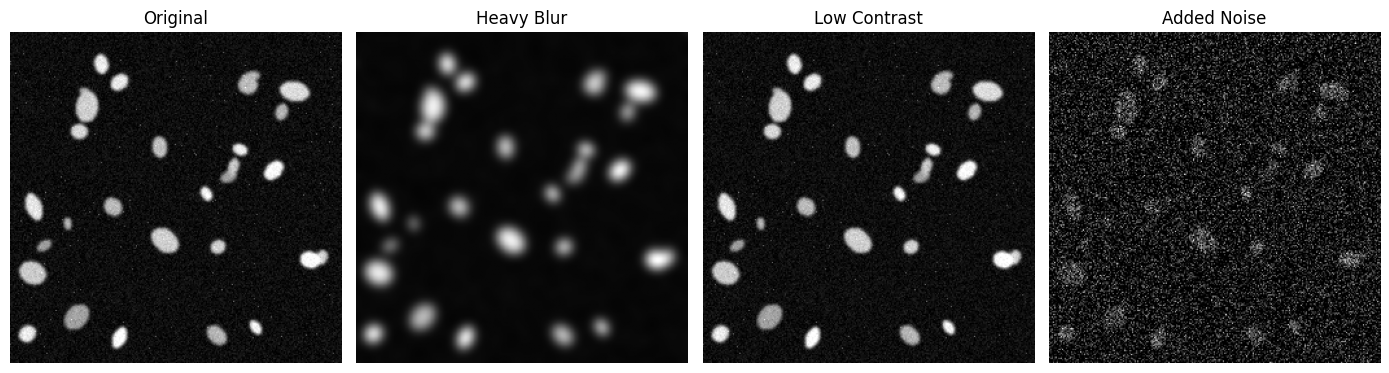

In [56]:
clean = preprocess_image(
    representative_path
)

blurred = apply_heavy_blur(clean)

low_contrast = apply_low_contrast(clean)

noisy = apply_noise(clean)


plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(clean, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Heavy Blur")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(low_contrast, cmap="gray")
plt.title("Low Contrast")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(noisy, cmap="gray")
plt.title("Added Noise")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "extra_credit_corruption_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
print("Representative image:", representative_name)
print("Path:", representative_path)

task2_image = preprocess_image(representative_path)

print("Image shape:", task2_image.shape)
print("Intensity range:", task2_image.min(), "to", task2_image.max())

Representative image: train_033.png
Path: assignment_dataset\nuclei_dataset\train\images\train_033.png
Image shape: (256, 256)
Intensity range: 0.0 to 0.34678861


In [59]:
otsu_threshold = filters.threshold_otsu(task2_image)

binary_otsu = task2_image > otsu_threshold

print("Otsu threshold:", otsu_threshold)
print("Foreground pixels:", binary_otsu.sum())
print("Foreground fraction:", binary_otsu.mean())

Otsu threshold: 0.13614163
Foreground pixels: 4199
Foreground fraction: 0.0640716552734375


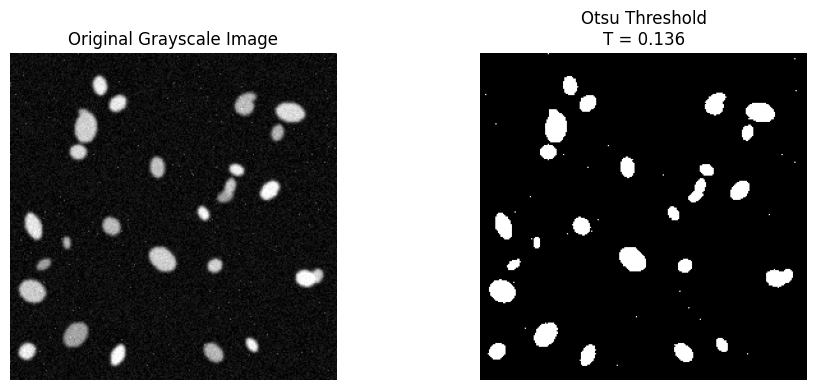

In [60]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(task2_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_otsu, cmap="gray")
plt.title(f"Otsu Threshold\nT = {otsu_threshold:.3f}")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "task2_otsu_raw.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
clean_mask = morphology.remove_small_objects(
    binary_otsu,
    max_size=19
)

clean_mask = morphology.remove_small_holes(
    clean_mask,
    max_size=19
)

print("Foreground pixels before cleanup:", binary_otsu.sum())
print("Foreground pixels after cleanup :", clean_mask.sum())

Foreground pixels before cleanup: 4199
Foreground pixels after cleanup : 4173


In [66]:
clean_mask = morphology.opening(
    clean_mask,
    morphology.disk(1)
)

clean_mask = morphology.closing(
    clean_mask,
    morphology.disk(1)
)

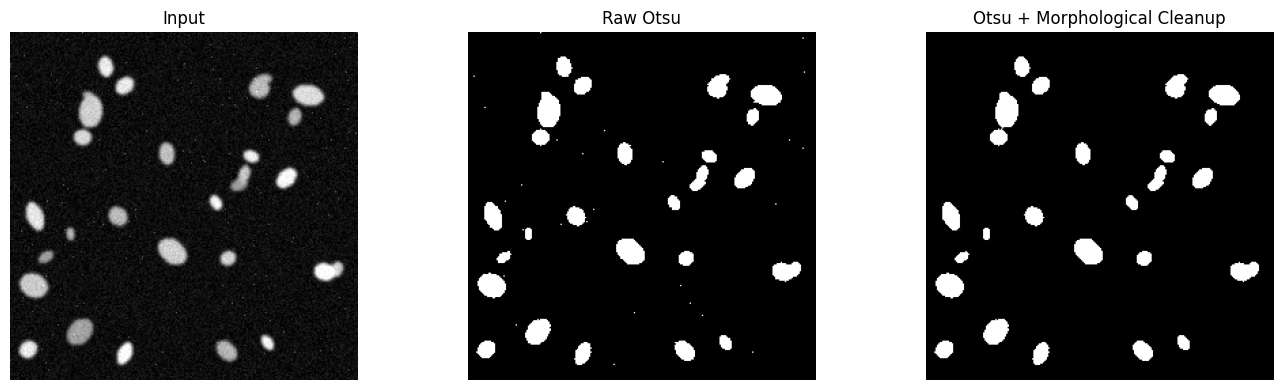

In [67]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(task2_image, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary_otsu, cmap="gray")
plt.title("Raw Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clean_mask, cmap="gray")
plt.title("Otsu + Morphological Cleanup")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "task2_otsu_cleanup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
label_image = measure.label(clean_mask)

n_objects = label_image.max()

print("Number of connected objects:", n_objects)

Number of connected objects: 24


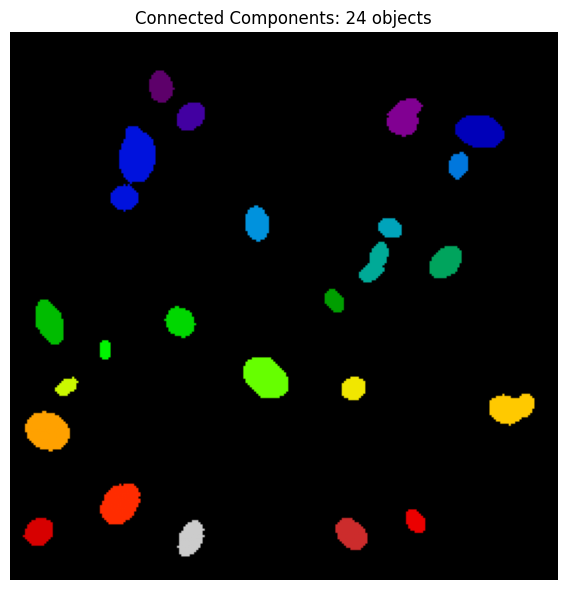

In [69]:
plt.figure(figsize=(6, 6))

plt.imshow(label_image, cmap="nipy_spectral")
plt.title(f"Connected Components: {n_objects} objects")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "task2_connected_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
properties = [
    "label",
    "area",
    "eccentricity",
    "solidity",
    "mean_intensity",
    "major_axis_length",
    "minor_axis_length",
    "equivalent_diameter_area",
    "perimeter"
]

feature_dict = regionprops_table(
    label_image,
    intensity_image=task2_image,
    properties=properties
)

feature_df = pd.DataFrame(feature_dict)

print("Feature table shape:", feature_df.shape)

display(feature_df.head())

Feature table shape: (24, 9)


,label,area,eccentricity,solidity,mean_intensity,major_axis_length,minor_axis_length,equivalent_diameter_area,perimeter
0,1,133.0,0.669472,0.956835,0.275351,15.101959,11.218298,13.013103,41.213203
1,2,212.0,0.663075,0.933921,0.227840,19.218917,14.386377,16.429449,55.941125
2,3,138.0,0.614019,0.971831,0.274692,14.904820,11.764246,13.255454,40.970563
3,4,277.0,0.755055,0.982270,0.270219,23.191856,15.206004,18.779972,60.284271
4,5,473.0,0.921322,0.819757,0.254516,42.903577,16.680908,24.540626,107.740115


In [71]:
display(feature_df.describe())

,label,area,eccentricity,solidity,mean_intensity,major_axis_length,minor_axis_length,equivalent_diameter_area,perimeter
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,172.750000,0.703073,0.955421,0.250198,17.796464,11.830296,14.290548,47.291631
std,7.071068,98.732511,0.122318,0.040296,0.030764,6.879152,3.230221,4.051713,17.638534
min,1.000000,41.000000,0.419310,0.819757,0.192911,9.596747,5.373830,7.225152,21.656854
25%,6.750000,97.250000,0.655610,0.937326,0.223073,12.438253,9.155661,11.124121,33.849242
50%,12.500000,150.500000,0.700606,0.968862,0.255390,16.778283,11.906048,13.842761,45.455844
75%,18.250000,216.500000,0.795566,0.979084,0.275307,21.566889,13.778966,16.600266,56.880465
max,24.000000,473.000000,0.921322,1.000000,0.291393,42.903577,17.393141,24.540626,107.740115


In [72]:
feature_df.to_csv(
    "task2_object_features.csv",
    index=False
)

print("Saved: task2_object_features.csv")

Saved: task2_object_features.csv


In [73]:
image_area = task2_image.shape[0] * task2_image.shape[1]

foreground_area = clean_mask.sum()

foreground_fraction = foreground_area / image_area

summary_features = {
    "n_objects": int(len(feature_df)),

    "mean_area": float(feature_df["area"].mean()),
    "median_area": float(feature_df["area"].median()),
    "std_area": float(feature_df["area"].std()),

    "mean_eccentricity": float(
        feature_df["eccentricity"].mean()
    ),

    "mean_solidity": float(
        feature_df["solidity"].mean()
    ),

    "mean_object_intensity": float(
        feature_df["mean_intensity"].mean()
    ),

    "mean_equivalent_diameter": float(
        feature_df["equivalent_diameter_area"].mean()
    ),

    "foreground_fraction": float(
        foreground_fraction
    )
}

print(json.dumps(summary_features, indent=4))

{
    "n_objects": 24,
    "mean_area": 172.75,
    "median_area": 150.5,
    "std_area": 98.73251083433549,
    "mean_eccentricity": 0.7030733240112861,
    "mean_solidity": 0.9554211053238669,
    "mean_object_intensity": 0.2501983791589737,
    "mean_equivalent_diameter": 14.29054835049984,
    "foreground_fraction": 0.063262939453125
}


In [74]:
def classify_density(n_objects, foreground_fraction):

    if n_objects < 20 and foreground_fraction < 0.10:
        return "low"

    elif n_objects < 50 and foreground_fraction < 0.25:
        return "moderate"

    else:
        return "high"


density_class = classify_density(
    summary_features["n_objects"],
    summary_features["foreground_fraction"]
)

summary_features["density_class"] = density_class

print("Density class:", density_class)

Density class: moderate


In [75]:
def classify_shape_regularity(mean_solidity, mean_eccentricity):

    if mean_solidity >= 0.90 and mean_eccentricity <= 0.65:
        return "regular"

    elif mean_solidity >= 0.80:
        return "moderately_regular"

    else:
        return "irregular"


shape_regularity = classify_shape_regularity(
    summary_features["mean_solidity"],
    summary_features["mean_eccentricity"]
)

summary_features["shape_regularity"] = shape_regularity

print("Shape regularity:", shape_regularity)

Shape regularity: moderately_regular


In [76]:
numbers_first_summary = f"""
Classical image analysis was performed using Otsu thresholding,
morphological cleanup, connected-component labelling and region-based
feature extraction.

Measured results:

Number of objects: {summary_features['n_objects']}
Mean object area: {summary_features['mean_area']:.2f} pixels
Median object area: {summary_features['median_area']:.2f} pixels
Object-area standard deviation: {summary_features['std_area']:.2f} pixels
Mean eccentricity: {summary_features['mean_eccentricity']:.3f}
Mean solidity: {summary_features['mean_solidity']:.3f}
Mean object intensity: {summary_features['mean_object_intensity']:.3f}
Mean equivalent diameter: {summary_features['mean_equivalent_diameter']:.2f} pixels
Foreground fraction: {summary_features['foreground_fraction']:.3f}
Density class: {summary_features['density_class']}
Shape regularity: {summary_features['shape_regularity']}
"""

print(numbers_first_summary)


Classical image analysis was performed using Otsu thresholding,
morphological cleanup, connected-component labelling and region-based
feature extraction.

Measured results:

Number of objects: 24
Mean object area: 172.75 pixels
Median object area: 150.50 pixels
Object-area standard deviation: 98.73 pixels
Mean eccentricity: 0.703
Mean solidity: 0.955
Mean object intensity: 0.250
Mean equivalent diameter: 14.29 pixels
Foreground fraction: 0.063
Density class: moderate
Shape regularity: moderately_regular



In [77]:
TEXT_MODEL = "llama3.2:latest"

OLLAMA_CHAT_URL = "http://localhost:11434/api/chat"

In [78]:
def query_text_llm(
    prompt,
    model=TEXT_MODEL,
    temperature=0.1
):

    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "stream": False,
        "options": {
            "temperature": temperature
        }
    }

    response = requests.post(
        OLLAMA_CHAT_URL,
        json=payload,
        timeout=300
    )

    if response.status_code != 200:
        print("Status:", response.status_code)
        print(response.text)
        response.raise_for_status()

    result = response.json()

    return result["message"]["content"]

In [79]:
test_response = query_text_llm(
    "Reply with only the word READY."
)

print(test_response)

READY


In [80]:
numbers_first_prompt = f"""
You are a data-analysis assistant interpreting quantitative image
measurements.

You have NOT been given the original image.

You must base your response ONLY on the numerical measurements supplied
below.

Do not invent:
- tissue type
- disease
- organ
- cell type
- stain
- species
- acquisition method

If something cannot be established from the numerical measurements,
state that it cannot be determined.

MEASUREMENTS
{numbers_first_summary}

TASK

Return valid JSON only, using exactly this schema:

{{
    "description": "one concise paragraph describing the image using only the supplied measurements",

    "n_objects": {summary_features['n_objects']},

    "density_class": "{summary_features['density_class']}",

    "shape_regularity": "{summary_features['shape_regularity']}",

    "quality_flag": "good, moderate, poor, or uncertain"
}}

IMPORTANT RULES

1. n_objects must remain exactly {summary_features['n_objects']}.
2. density_class must remain exactly "{summary_features['density_class']}".
3. shape_regularity must remain exactly "{summary_features['shape_regularity']}".
4. Do not recalculate or change those values.
5. quality_flag may be interpreted cautiously from the measurements.
6. Do not make diagnostic claims.
7. Do not include Markdown.
8. Do not include any text outside the JSON object.
"""

print(numbers_first_prompt)


You are a data-analysis assistant interpreting quantitative image
measurements.

You have NOT been given the original image.

You must base your response ONLY on the numerical measurements supplied
below.

Do not invent:
- tissue type
- disease
- organ
- cell type
- stain
- species
- acquisition method

If something cannot be established from the numerical measurements,
state that it cannot be determined.

MEASUREMENTS

Classical image analysis was performed using Otsu thresholding,
morphological cleanup, connected-component labelling and region-based
feature extraction.

Measured results:

Number of objects: 24
Mean object area: 172.75 pixels
Median object area: 150.50 pixels
Object-area standard deviation: 98.73 pixels
Mean eccentricity: 0.703
Mean solidity: 0.955
Mean object intensity: 0.250
Mean equivalent diameter: 14.29 pixels
Foreground fraction: 0.063
Density class: moderate
Shape regularity: moderately_regular


TASK

Return valid JSON only, using exactly this schema:

{
    

In [81]:
numbers_first_response = query_text_llm(
    numbers_first_prompt
)

print("NUMBERS-FIRST LLM RESPONSE")
print("--------------------------")
print(numbers_first_response)

NUMBERS-FIRST LLM RESPONSE
--------------------------
{
    "description": "The image contains 24 objects with moderate density and moderately regular shapes, indicating a relatively uniform distribution of features.",
    "n_objects": 24,
    "density_class": "moderate",
    "shape_regularity": "moderately_regular",
    "quality_flag": "uncertain"
}


In [82]:
try:

    numbers_first_json = json.loads(
        numbers_first_response
    )

    print("Valid JSON ✓")

    print(
        json.dumps(
            numbers_first_json,
            indent=4
        )
    )

except json.JSONDecodeError as e:

    print("Invalid JSON ✗")
    print(e)

    numbers_first_json = None

Valid JSON ✓
{
    "description": "The image contains 24 objects with moderate density and moderately regular shapes, indicating a relatively uniform distribution of features.",
    "n_objects": 24,
    "density_class": "moderate",
    "shape_regularity": "moderately_regular",
    "quality_flag": "uncertain"
}


In [84]:
if numbers_first_json is not None:

    checks = {
        "n_objects":
            numbers_first_json["n_objects"]
            == summary_features["n_objects"],

        "density_class":
            numbers_first_json["density_class"]
            == summary_features["density_class"],

        "shape_regularity":
            numbers_first_json["shape_regularity"]
            == summary_features["shape_regularity"]
    }

    print("VALIDATION CHECKS")

    for key, passed in checks.items():

        symbol = "T" if passed else "F"

        print(f"{symbol} {key}: {passed}")

VALIDATION CHECKS
T n_objects: True
T density_class: True
T shape_regularity: True


In [85]:
task2_results = {
    "image_id": representative_name,
    "otsu_threshold": float(otsu_threshold),
    "summary_features": summary_features,
    "llm_prompt": numbers_first_prompt,
    "llm_output": numbers_first_json
}

with open(
    "task2_numbers_first_results.json",
    "w"
) as f:

    json.dump(
        task2_results,
        f,
        indent=4
    )

print("Saved: task2_numbers_first_results.json")

Saved: task2_numbers_first_results.json


In [86]:
gt_mask_path = TRAIN_MASK_DIR / representative_name

gt_mask = io.imread(gt_mask_path)

gt_mask = gt_mask > 0

print("GT shape:", gt_mask.shape)
print("GT foreground pixels:", gt_mask.sum())

GT shape: (256, 256)
GT foreground pixels: 4119


In [87]:
def dice_score(pred, target, smooth=1e-8):

    pred = pred.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    return (
        2 * intersection + smooth
    ) / (
        pred.sum()
        + target.sum()
        + smooth
    )


def iou_score(pred, target, smooth=1e-8):

    pred = pred.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    union = np.logical_or(
        pred,
        target
    ).sum()

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

In [88]:
otsu_dice = dice_score(
    clean_mask,
    gt_mask
)

otsu_iou = iou_score(
    clean_mask,
    gt_mask
)

print(f"Otsu Dice: {otsu_dice:.4f}")
print(f"Otsu IoU : {otsu_iou:.4f}")

Otsu Dice: 0.9803
Otsu IoU : 0.9613


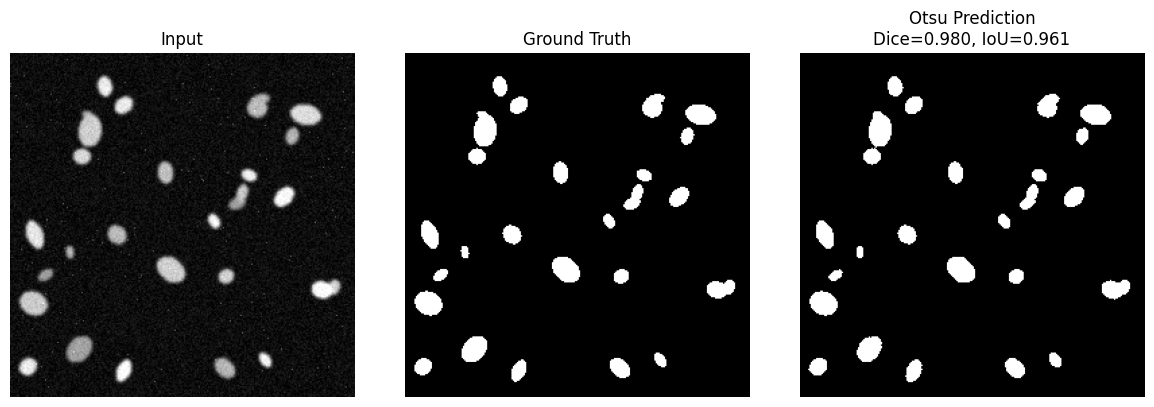

In [89]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(task2_image, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clean_mask, cmap="gray")
plt.title(
    f"Otsu Prediction\n"
    f"Dice={otsu_dice:.3f}, IoU={otsu_iou:.3f}"
)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "task2_otsu_vs_ground_truth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
val_otsu_results = []

for image_path in val_image_paths:

    image = preprocess_image(image_path)

    threshold = filters.threshold_otsu(image)

    pred = image > threshold

    # Updated morphology syntax for newer scikit-image
    pred = morphology.remove_small_objects(
        pred,
        max_size=19
    )

    pred = morphology.remove_small_holes(
        pred,
        max_size=19
    )

    pred = morphology.opening(
        pred,
        morphology.disk(1)
    )

    pred = morphology.closing(
        pred,
        morphology.disk(1)
    )

    gt_path = VAL_MASK_DIR / image_path.name

    gt = io.imread(gt_path) > 0

    dice = dice_score(pred, gt)
    iou = iou_score(pred, gt)

    val_otsu_results.append({
        "image_id": image_path.name,
        "dice": dice,
        "iou": iou
    })

print("Finished Otsu evaluation on validation set.")

Finished Otsu evaluation on validation set.


In [93]:
otsu_val_df = pd.DataFrame(
    val_otsu_results
)

display(otsu_val_df)

,image_id,dice,iou
0,val_000.png,0.978428,0.957768
1,val_001.png,0.977027,0.955086
2,val_002.png,0.981650,0.963961
3,val_003.png,0.976989,0.955012
4,val_004.png,0.975597,0.952356
5,val_005.png,0.975957,0.953043
6,val_006.png,0.973759,0.948860
7,val_007.png,0.978969,0.958804
8,val_008.png,0.983015,0.966598
9,val_009.png,0.975554,0.952276


In [94]:
mean_otsu_dice = otsu_val_df["dice"].mean()

mean_otsu_iou = otsu_val_df["iou"].mean()

std_otsu_dice = otsu_val_df["dice"].std()

std_otsu_iou = otsu_val_df["iou"].std()


print(
    f"Mean validation Otsu Dice: "
    f"{mean_otsu_dice:.4f} ± {std_otsu_dice:.4f}"
)

print(
    f"Mean validation Otsu IoU : "
    f"{mean_otsu_iou:.4f} ± {std_otsu_iou:.4f}"
)

Mean validation Otsu Dice: 0.9782 ± 0.0027
Mean validation Otsu IoU : 0.9574 ± 0.0052


In [95]:
otsu_val_df.to_csv(
    "task2_otsu_validation_metrics.csv",
    index=False
)

print(
    "Saved: task2_otsu_validation_metrics.csv"
)

Saved: task2_otsu_validation_metrics.csv


In [96]:
print("=" * 70)
print("TASK 1 — DIRECT IMAGE/VLM DESCRIPTION")
print("=" * 70)

if structured_vlm_result is not None:
    print(
        json.dumps(
            structured_vlm_result,
            indent=4
        )
    )
else:
    print(optimised_response)


print("\n" + "=" * 70)
print("TASK 2 — NUMBERS-FIRST DESCRIPTION")
print("=" * 70)

if numbers_first_json is not None:
    print(
        json.dumps(
            numbers_first_json,
            indent=4
        )
    )

TASK 1 — DIRECT IMAGE/VLM DESCRIPTION
{
    "modality": "fluorescence microscopy",
    "tissue_type": "uncertain",
    "notable_features": [
        "grayish oval shapes scattered across the field of view"
    ],
    "image_quality": {
        "overall": "good",
        "contrast": "high",
        "noise": "low",
        "issues": []
    }
}

TASK 2 — NUMBERS-FIRST DESCRIPTION
{
    "description": "The image contains 24 objects with moderate density and moderately regular shapes, indicating a relatively uniform distribution of features.",
    "n_objects": 24,
    "density_class": "moderate",
    "shape_regularity": "moderately_regular",
    "quality_flag": "uncertain"
}


In [97]:
task1_task2_comparison = pd.DataFrame({

    "Aspect": [
        "Input to LLM",
        "Can directly see image",
        "Object count grounded in code",
        "Shape measurements grounded in code",
        "Risk of visual hallucination",
        "Auditability",
        "Can describe subtle visual appearance",
        "Numerical reproducibility"
    ],

    "Task 1 Direct VLM": [
        "Image",
        "Yes",
        "No",
        "No",
        "Higher",
        "Lower",
        "Yes",
        "Lower"
    ],

    "Task 2 Numbers-First": [
        "Measured numerical features only",
        "No",
        "Yes",
        "Yes",
        "Lower",
        "Higher",
        "Limited",
        "Higher"
    ]
})

display(task1_task2_comparison)

,Aspect,Task 1 Direct VLM,Task 2 Numbers-First
0,Input to LLM,Image,Measured numerical features only
1,Can directly see image,Yes,No
2,Object count grounded in code,No,Yes
3,Shape measurements grounded in code,No,Yes
4,Risk of visual hallucination,Higher,Lower
5,Auditability,Lower,Higher
6,Can describe subtle visual appearance,Yes,Limited
7,Numerical reproducibility,Lower,Higher


In [98]:
task1_task2_comparison.to_csv(
    "task1_vs_task2_comparison.csv",
    index=False
)

print(
    "Saved: task1_vs_task2_comparison.csv"
)

Saved: task1_vs_task2_comparison.csv


In [99]:
def extract_classical_features(image):

    threshold = filters.threshold_otsu(image)

    mask = image > threshold

    mask = morphology.remove_small_objects(
        mask,
        min_size=20
    )

    mask = morphology.remove_small_holes(
        mask,
        area_threshold=20
    )

    mask = morphology.binary_opening(
        mask,
        morphology.disk(1)
    )

    mask = morphology.binary_closing(
        mask,
        morphology.disk(1)
    )

    labels = measure.label(mask)

    props = regionprops_table(
        labels,
        intensity_image=image,
        properties=[
            "label",
            "area",
            "eccentricity",
            "solidity",
            "mean_intensity",
            "equivalent_diameter_area"
        ]
    )

    df = pd.DataFrame(props)

    if len(df) == 0:

        summary = {
            "n_objects": 0,
            "mean_area": 0,
            "mean_eccentricity": 0,
            "mean_solidity": 0,
            "mean_intensity": 0,
            "foreground_fraction": float(mask.mean())
        }

    else:

        summary = {
            "n_objects": int(len(df)),
            "mean_area": float(
                df["area"].mean()
            ),
            "mean_eccentricity": float(
                df["eccentricity"].mean()
            ),
            "mean_solidity": float(
                df["solidity"].mean()
            ),
            "mean_intensity": float(
                df["mean_intensity"].mean()
            ),
            "foreground_fraction": float(
                mask.mean()
            )
        }

    return mask, labels, df, summary

In [1]:
import sys
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(torch.rand(2, 3))

Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Torch: 2.8.0+cpu
CUDA available: False
tensor([[0.0388, 0.5574, 0.9587],
        [0.9186, 0.7011, 0.6718]])


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [9]:
from pathlib import Path

# Change this only if your extracted dataset folder is somewhere else
DATA_ROOT = Path("assignment_dataset") / "nuclei_dataset"

TRAIN_IMG_DIR = DATA_ROOT / "train" / "images"
TRAIN_MASK_DIR = DATA_ROOT / "train" / "masks"

VAL_IMG_DIR = DATA_ROOT / "val" / "images"
VAL_MASK_DIR = DATA_ROOT / "val" / "masks"

TEST_IMG_DIR = DATA_ROOT / "test" / "images"
TEST_MASK_DIR = DATA_ROOT / "test" / "masks"

train_image_paths = sorted(TRAIN_IMG_DIR.glob("*.png"))
val_image_paths = sorted(VAL_IMG_DIR.glob("*.png"))
test_image_paths = sorted(TEST_IMG_DIR.glob("*.png"))

print("Training images   :", len(train_image_paths))
print("Validation images :", len(val_image_paths))
print("Test images       :", len(test_image_paths))

print("Training mask dir :", TRAIN_MASK_DIR)
print("Validation mask dir:", VAL_MASK_DIR)

Training images   : 80
Validation images : 20
Test images       : 12
Training mask dir : assignment_dataset\nuclei_dataset\train\masks
Validation mask dir: assignment_dataset\nuclei_dataset\val\masks


In [10]:
import numpy as np
from skimage import io, color, transform

def preprocess_image(image_path, output_size=(256, 256)):

    image = io.imread(image_path)

    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = color.rgba2rgb(image)

        image = color.rgb2gray(image)

    image = transform.resize(
        image,
        output_size,
        preserve_range=False,
        anti_aliasing=True
    )

    return image.astype(np.float32)

In [11]:
print("Training images   :", len(train_image_paths))
print("Validation images :", len(val_image_paths))

print("Training mask dir :", TRAIN_MASK_DIR)
print("Validation mask dir:", VAL_MASK_DIR)

Training images   : 80
Validation images : 20
Training mask dir : assignment_dataset\nuclei_dataset\train\masks
Validation mask dir: assignment_dataset\nuclei_dataset\val\masks


In [12]:
sample_path = train_image_paths[0]
sample_mask_path = TRAIN_MASK_DIR / sample_path.name

print("Image exists:", sample_path.exists())
print("Mask exists :", sample_mask_path.exists())
print("Example image:", sample_path.name)

Image exists: True
Mask exists : True
Example image: train_000.png


In [13]:
class NucleiDataset(Dataset):

    def __init__(
        self,
        image_paths,
        mask_dir,
        augment=False
    ):
        self.image_paths = list(image_paths)
        self.mask_dir = mask_dir
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        # Use same preprocessing as Tasks 1 and 2
        image = preprocess_image(image_path)

        mask = io.imread(mask_path)

        # Convert mask to binary
        mask = (mask > 0).astype(np.float32)

        # Convert to PyTorch tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        # Simple paired augmentation
        if self.augment:

            if random.random() > 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[2])

            if random.random() > 0.5:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[1])

        return image, mask, image_path.name

In [14]:
train_dataset = NucleiDataset(
    train_image_paths,
    TRAIN_MASK_DIR,
    augment=True
)

val_dataset = NucleiDataset(
    val_image_paths,
    VAL_MASK_DIR,
    augment=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 80
Validation samples: 20


In [16]:
sample_image, sample_mask, sample_name = train_dataset[0]

print("Image:", sample_name)
print("Image tensor shape:", sample_image.shape)
print("Mask tensor shape :", sample_mask.shape)

print(
    "Image range:",
    sample_image.min().item(),
    "to",
    sample_image.max().item()
)

print(
    "Mask values:",
    torch.unique(sample_mask)
)

Image: train_000.png
Image tensor shape: torch.Size([1, 256, 256])
Mask tensor shape : torch.Size([1, 256, 256])
Image range: 0.0 to 0.346788614988327
Mask values: tensor([0., 1.])


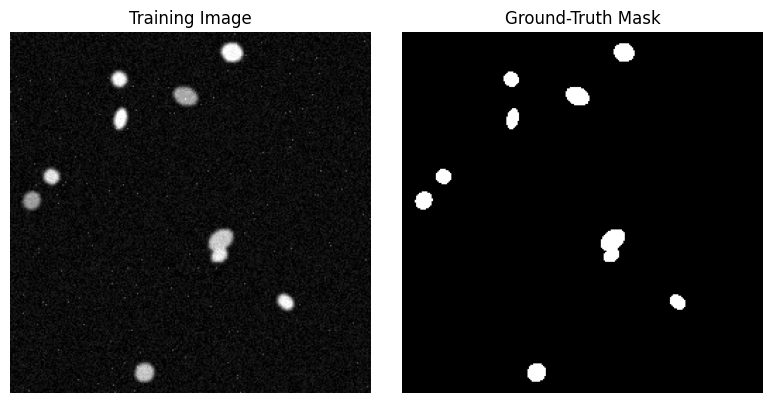

In [17]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    sample_image.squeeze().numpy(),
    cmap="gray"
)
plt.title("Training Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    sample_mask.squeeze().numpy(),
    cmap="gray"
)
plt.title("Ground-Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 20
Validation batches: 5


In [19]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [20]:
class SmallUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(
            64,
            128
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            128,
            64
        )

        self.up2 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            64,
            32
        )

        self.up1 = nn.ConvTranspose2d(
            32,
            16,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            32,
            16
        )

        self.output = nn.Conv2d(
            16,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool3(e3)
        )

        # Decoder 3
        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        # Decoder 2
        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        # Decoder 1
        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        logits = self.output(d1)

        return logits

In [21]:
model = SmallUNet().to(device)

print(model)

SmallUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  

In [22]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 483,153
Trainable parameters: 483,153


In [23]:
bce_loss_fn = nn.BCEWithLogitsLoss()

In [24]:
def dice_coefficient_torch(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities > threshold
    ).float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return dice.mean()

In [25]:
def dice_loss(
    logits,
    targets,
    smooth=1e-7
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = probabilities.view(
        probabilities.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        probabilities * targets
    ).sum(dim=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return 1.0 - dice.mean()

In [26]:
def bce_dice_loss(
    logits,
    targets
):

    bce = bce_loss_fn(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return bce + dice

In [27]:
def iou_coefficient_torch(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-7
):

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities > threshold
    ).float()

    predictions = predictions.view(
        predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    union = (
        predictions
        + targets
        - predictions * targets
    ).sum(dim=1)

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.mean()

In [28]:
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(
    "Learning rate:",
    LEARNING_RATE
)

Learning rate: 0.001


In [29]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_function,
    device
):

    model.train()

    running_loss = 0.0
    running_dice = 0.0

    for images, masks, _ in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = loss_function(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        dice = dice_coefficient_torch(
            logits.detach(),
            masks
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        running_dice += (
            dice.item()
            * images.size(0)
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    epoch_dice = (
        running_dice
        / len(loader.dataset)
    )

    return epoch_loss, epoch_dice

In [30]:
def validate_one_epoch(
    model,
    loader,
    loss_function,
    device
):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    with torch.no_grad():

        for images, masks, _ in loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            loss = loss_function(
                logits,
                masks
            )

            dice = dice_coefficient_torch(
                logits,
                masks
            )

            iou = iou_coefficient_torch(
                logits,
                masks
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            running_dice += (
                dice.item()
                * images.size(0)
            )

            running_iou += (
                iou.item()
                * images.size(0)
            )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    epoch_dice = (
        running_dice
        / len(loader.dataset)
    )

    epoch_iou = (
        running_iou
        / len(loader.dataset)
    )

    return (
        epoch_loss,
        epoch_dice,
        epoch_iou
    )

In [31]:
EPOCHS = 15

model = SmallUNet().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "val_iou": []
}

In [32]:
for epoch in range(EPOCHS):

    train_loss, train_dice = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            bce_dice_loss,
            device
        )
    )

    val_loss, val_dice, val_iou = (
        validate_one_epoch(
            model,
            val_loader,
            bce_dice_loss,
            device
        )
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_dice"].append(
        train_dice
    )

    history["val_dice"].append(
        val_dice
    )

    history["val_iou"].append(
        val_iou
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

Epoch 01/15 | Train Loss: 1.1870 | Val Loss: 1.3628 | Train Dice: 0.8406 | Val Dice: 0.2632 | Val IoU: 0.1541
Epoch 02/15 | Train Loss: 1.0390 | Val Loss: 1.0419 | Train Dice: 0.9213 | Val Dice: 0.8660 | Val IoU: 0.7641
Epoch 03/15 | Train Loss: 0.9464 | Val Loss: 0.9371 | Train Dice: 0.9454 | Val Dice: 0.9132 | Val IoU: 0.8406
Epoch 04/15 | Train Loss: 0.8735 | Val Loss: 0.8615 | Train Dice: 0.9600 | Val Dice: 0.9749 | Val IoU: 0.9511
Epoch 05/15 | Train Loss: 0.8004 | Val Loss: 0.7965 | Train Dice: 0.9735 | Val Dice: 0.9795 | Val IoU: 0.9598
Epoch 06/15 | Train Loss: 0.7299 | Val Loss: 0.7447 | Train Dice: 0.9793 | Val Dice: 0.9926 | Val IoU: 0.9853
Epoch 07/15 | Train Loss: 0.6612 | Val Loss: 0.6640 | Train Dice: 0.9836 | Val Dice: 0.9935 | Val IoU: 0.9871
Epoch 08/15 | Train Loss: 0.5946 | Val Loss: 0.5748 | Train Dice: 0.9851 | Val Dice: 0.9933 | Val IoU: 0.9866
Epoch 09/15 | Train Loss: 0.5294 | Val Loss: 0.4823 | Train Dice: 0.9887 | Val Dice: 0.9908 | Val IoU: 0.9818
Epoch 10/1

In [33]:
torch.save(
    model.state_dict(),
    "task3_unet_bce_dice.pth"
)

print(
    "Saved: task3_unet_bce_dice.pth"
)

Saved: task3_unet_bce_dice.pth


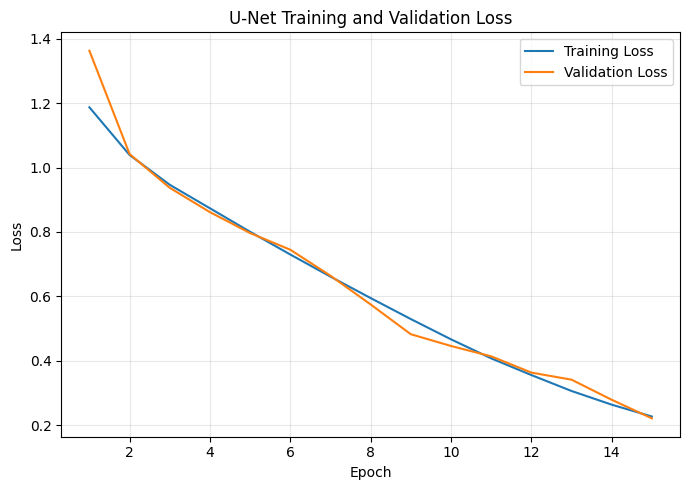

In [34]:
epochs_range = range(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "task3_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

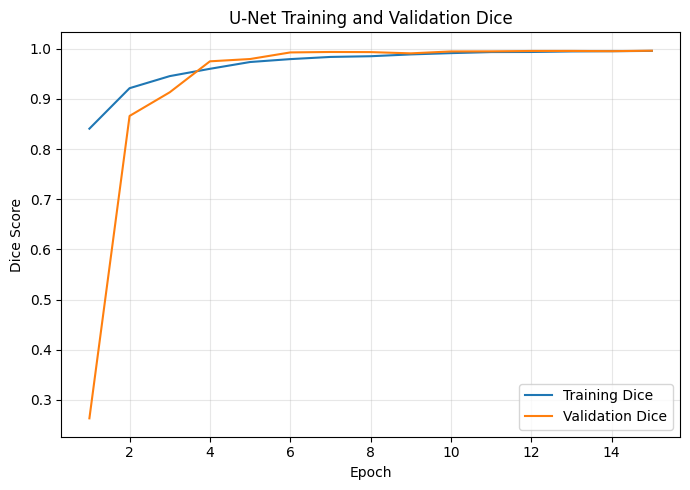

In [35]:
plt.figure(figsize=(7, 5))

plt.plot(
    epochs_range,
    history["train_dice"],
    label="Training Dice"
)

plt.plot(
    epochs_range,
    history["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")

plt.title(
    "U-Net Training and Validation Dice"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "task3_dice_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
final_val_loss, final_val_dice, final_val_iou = (
    validate_one_epoch(
        model,
        val_loader,
        bce_dice_loss,
        device
    )
)

print(
    f"Final validation loss: "
    f"{final_val_loss:.4f}"
)

print(
    f"Mean validation Dice: "
    f"{final_val_dice:.4f}"
)

print(
    f"Mean validation IoU: "
    f"{final_val_iou:.4f}"
)

Final validation loss: 0.2210
Mean validation Dice: 0.9960
Mean validation IoU: 0.9921


In [37]:
def evaluate_per_image(
    model,
    dataset,
    device
):

    model.eval()

    results = []

    with torch.no_grad():

        for i in range(len(dataset)):

            image, mask, name = dataset[i]

            image_batch = (
                image
                .unsqueeze(0)
                .to(device)
            )

            mask_batch = (
                mask
                .unsqueeze(0)
                .to(device)
            )

            logits = model(
                image_batch
            )

            dice = (
                dice_coefficient_torch(
                    logits,
                    mask_batch
                ).item()
            )

            iou = (
                iou_coefficient_torch(
                    logits,
                    mask_batch
                ).item()
            )

            results.append({
                "image_id": name,
                "dice": dice,
                "iou": iou
            })

    return pd.DataFrame(results)

In [38]:
unet_val_df = evaluate_per_image(
    model,
    val_dataset,
    device
)

display(unet_val_df)

,image_id,dice,iou
0,val_000.png,0.994536,0.989130
1,val_001.png,0.994836,0.989725
2,val_002.png,0.997310,0.994635
3,val_003.png,0.996306,0.992639
4,val_004.png,0.995868,0.991770
5,val_005.png,0.995197,0.990440
6,val_006.png,0.994866,0.989784
7,val_007.png,0.996968,0.993955
8,val_008.png,0.998099,0.996205
9,val_009.png,0.995456,0.990953


In [39]:
unet_val_df.to_csv(
    "task3_unet_validation_metrics.csv",
    index=False
)

print(
    "Saved: task3_unet_validation_metrics.csv"
)

Saved: task3_unet_validation_metrics.csv


In [40]:
print("BEST U-NET VALIDATION RESULTS")

display(
    unet_val_df
    .sort_values(
        "dice",
        ascending=False
    )
    .head(5)
)


print(
    "\nWORST U-NET VALIDATION RESULTS"
)

display(
    unet_val_df
    .sort_values(
        "dice",
        ascending=True
    )
    .head(5)
)

BEST U-NET VALIDATION RESULTS


,image_id,dice,iou
8,val_008.png,0.998099,0.996205
19,val_019.png,0.997914,0.995836
2,val_002.png,0.997310,0.994635
13,val_013.png,0.997196,0.994407
7,val_007.png,0.996968,0.993955



WORST U-NET VALIDATION RESULTS


,image_id,dice,iou
0,val_000.png,0.994536,0.989130
1,val_001.png,0.994836,0.989725
6,val_006.png,0.994866,0.989784
12,val_012.png,0.994888,0.989828
5,val_005.png,0.995197,0.990440


In [41]:
def predict_mask(
    model,
    image_tensor,
    device,
    threshold=0.5
):

    model.eval()

    with torch.no_grad():

        image_batch = (
            image_tensor
            .unsqueeze(0)
            .to(device)
        )

        logits = model(
            image_batch
        )

        probability = torch.sigmoid(
            logits
        )

        prediction = (
            probability > threshold
        ).float()

    return (
        prediction
        .squeeze()
        .cpu()
        .numpy()
    )

In [42]:
sorted_results = (
    unet_val_df
    .sort_values("dice")
    .reset_index(drop=True)
)

worst_name = sorted_results.iloc[0]["image_id"]

middle_name = sorted_results.iloc[
    len(sorted_results) // 2
]["image_id"]

best_name = sorted_results.iloc[-1]["image_id"]

selected_names = [
    best_name,
    middle_name,
    worst_name
]

print(
    "Selected validation examples:",
    selected_names
)

Selected validation examples: ['val_008.png', 'val_018.png', 'val_000.png']


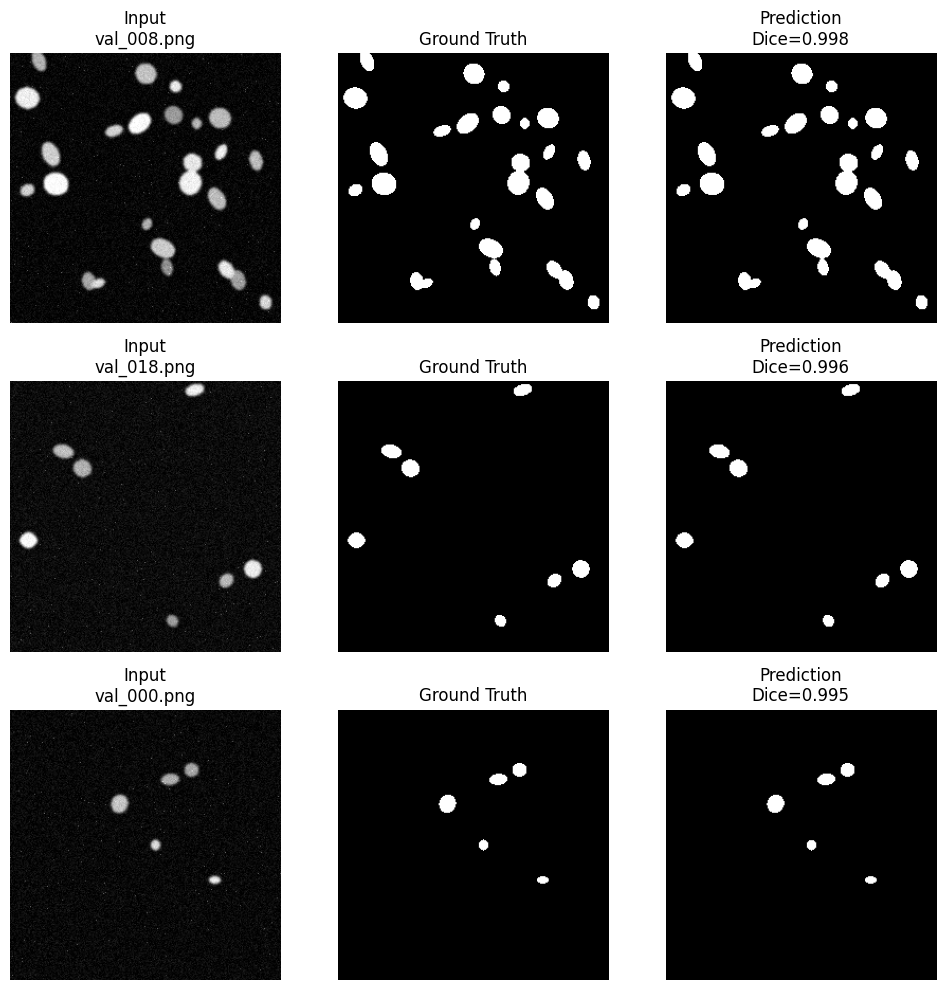

In [43]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 10)
)

for row, name in enumerate(selected_names):

    idx = [
        p.name
        for p in val_image_paths
    ].index(name)

    image, mask, _ = val_dataset[idx]

    pred = predict_mask(
        model,
        image,
        device
    )

    dice_value = float(
        unet_val_df.loc[
            unet_val_df["image_id"] == name,
            "dice"
        ].iloc[0]
    )

    axes[row, 0].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"Input\n{name}"
    )

    axes[row, 1].imshow(
        mask.squeeze(),
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Ground Truth"
    )

    axes[row, 2].imshow(
        pred,
        cmap="gray"
    )

    axes[row, 2].set_title(
        f"Prediction\nDice={dice_value:.3f}"
    )

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()

plt.savefig(
    "task3_validation_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
import pandas as pd

otsu_val_df = pd.read_csv(
    "task2_otsu_validation_metrics.csv"
)

display(otsu_val_df.head())

,image_id,dice,iou
0,val_000.png,0.978428,0.957768
1,val_001.png,0.977027,0.955086
2,val_002.png,0.981650,0.963961
3,val_003.png,0.976989,0.955012
4,val_004.png,0.975597,0.952356


In [47]:
comparison_metrics = pd.merge(
    otsu_val_df,
    unet_val_df,
    on="image_id",
    suffixes=(
        "_otsu",
        "_unet"
    )
)

comparison_metrics["dice_improvement"] = (
    comparison_metrics["dice_unet"]
    - comparison_metrics["dice_otsu"]
)

comparison_metrics["iou_improvement"] = (
    comparison_metrics["iou_unet"]
    - comparison_metrics["iou_otsu"]
)

display(comparison_metrics)

,image_id,dice_otsu,iou_otsu,dice_unet,iou_unet,dice_improvement,iou_improvement
0,val_000.png,0.978428,0.957768,0.994536,0.989130,0.016107,0.031363
1,val_001.png,0.977027,0.955086,0.994836,0.989725,0.017809,0.034639
2,val_002.png,0.981650,0.963961,0.997310,0.994635,0.015661,0.030674
3,val_003.png,0.976989,0.955012,0.996306,0.992639,0.019318,0.037627
4,val_004.png,0.975597,0.952356,0.995868,0.991770,0.020271,0.039414
5,val_005.png,0.975957,0.953043,0.995197,0.990440,0.019240,0.037397
6,val_006.png,0.973759,0.948860,0.994866,0.989784,0.021107,0.040924
7,val_007.png,0.978969,0.958804,0.996968,0.993955,0.017999,0.035150
8,val_008.png,0.983015,0.966598,0.998099,0.996205,0.015083,0.029607
9,val_009.png,0.975554,0.952276,0.995456,0.990953,0.019902,0.038678


In [48]:
print(
    "OTSU"
)

print(
    f"Mean Dice: "
    f"{comparison_metrics['dice_otsu'].mean():.4f}"
)

print(
    f"Mean IoU : "
    f"{comparison_metrics['iou_otsu'].mean():.4f}"
)


print(
    "\nU-NET"
)

print(
    f"Mean Dice: "
    f"{comparison_metrics['dice_unet'].mean():.4f}"
)

print(
    f"Mean IoU : "
    f"{comparison_metrics['iou_unet'].mean():.4f}"
)


print(
    "\nMEAN IMPROVEMENT"
)

print(
    f"Dice improvement: "
    f"{comparison_metrics['dice_improvement'].mean():+.4f}"
)

print(
    f"IoU improvement : "
    f"{comparison_metrics['iou_improvement'].mean():+.4f}"
)

OTSU
Mean Dice: 0.9782
Mean IoU : 0.9574

U-NET
Mean Dice: 0.9960
Mean IoU : 0.9921

MEAN IMPROVEMENT
Dice improvement: +0.0178
IoU improvement : +0.0348


In [49]:
comparison_metrics["winner"] = np.where(
    comparison_metrics["dice_unet"]
    > comparison_metrics["dice_otsu"],
    "U-Net",
    "Otsu"
)

display(
    comparison_metrics[
        [
            "image_id",
            "dice_otsu",
            "dice_unet",
            "dice_improvement",
            "winner"
        ]
    ]
)

,image_id,dice_otsu,dice_unet,dice_improvement,winner
0,val_000.png,0.978428,0.994536,0.016107,U-Net
1,val_001.png,0.977027,0.994836,0.017809,U-Net
2,val_002.png,0.981650,0.997310,0.015661,U-Net
3,val_003.png,0.976989,0.996306,0.019318,U-Net
4,val_004.png,0.975597,0.995868,0.020271,U-Net
5,val_005.png,0.975957,0.995197,0.019240,U-Net
6,val_006.png,0.973759,0.994866,0.021107,U-Net
7,val_007.png,0.978969,0.996968,0.017999,U-Net
8,val_008.png,0.983015,0.998099,0.015083,U-Net
9,val_009.png,0.975554,0.995456,0.019902,U-Net


In [50]:
print(
    comparison_metrics["winner"]
    .value_counts()
)

winner
U-Net    20
Name: count, dtype: int64


In [51]:
best_improvement_row = (
    comparison_metrics
    .sort_values(
        "dice_improvement",
        ascending=False
    )
    .iloc[0]
)

print(best_improvement_row)

image_id            val_019.png
dice_otsu              0.975749
iou_otsu               0.952645
dice_unet              0.997914
iou_unet               0.995836
dice_improvement       0.022165
iou_improvement         0.04319
winner                    U-Net
Name: 19, dtype: object


In [52]:
otsu_better = (
    comparison_metrics[
        comparison_metrics[
            "dice_improvement"
        ] < 0
    ]
)

if len(otsu_better) > 0:

    display(
        otsu_better
        .sort_values(
            "dice_improvement"
        )
        .head()
    )

else:

    print(
        "U-Net outperformed or matched "
        "Otsu on every validation image."
    )

U-Net outperformed or matched Otsu on every validation image.


In [53]:
comparison_metrics.to_csv(
    "task3_otsu_vs_unet.csv",
    index=False
)

print(
    "Saved: task3_otsu_vs_unet.csv"
)

Saved: task3_otsu_vs_unet.csv


In [54]:
def run_loss_experiment(
    loss_name,
    loss_function,
    epochs=8
):

    experiment_model = (
        SmallUNet().to(device)
    )

    experiment_optimizer = (
        torch.optim.Adam(
            experiment_model.parameters(),
            lr=LEARNING_RATE
        )
    )

    experiment_history = {
        "train_loss": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": []
    }

    print(
        f"\nTraining with {loss_name}"
    )

    for epoch in range(epochs):

        train_loss, _ = (
            train_one_epoch(
                experiment_model,
                train_loader,
                experiment_optimizer,
                loss_function,
                device
            )
        )

        val_loss, val_dice, val_iou = (
            validate_one_epoch(
                experiment_model,
                val_loader,
                loss_function,
                device
            )
        )

        experiment_history[
            "train_loss"
        ].append(train_loss)

        experiment_history[
            "val_loss"
        ].append(val_loss)

        experiment_history[
            "val_dice"
        ].append(val_dice)

        experiment_history[
            "val_iou"
        ].append(val_iou)

        print(
            f"{loss_name} | "
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Val Dice={val_dice:.4f} | "
            f"Val IoU={val_iou:.4f}"
        )

    return (
        experiment_model,
        experiment_history
    )

In [55]:
def bce_only_loss(
    logits,
    targets
):
    return bce_loss_fn(
        logits,
        targets
    )

In [56]:
bce_model, bce_history = (
    run_loss_experiment(
        "BCE",
        bce_only_loss,
        epochs=8
    )
)


Training with BCE
BCE | Epoch 01/8 | Val Dice=0.0000 | Val IoU=0.0000
BCE | Epoch 02/8 | Val Dice=0.8416 | Val IoU=0.7279
BCE | Epoch 03/8 | Val Dice=0.9598 | Val IoU=0.9227
BCE | Epoch 04/8 | Val Dice=0.9815 | Val IoU=0.9637
BCE | Epoch 05/8 | Val Dice=0.9938 | Val IoU=0.9876
BCE | Epoch 06/8 | Val Dice=0.9904 | Val IoU=0.9810
BCE | Epoch 07/8 | Val Dice=0.9932 | Val IoU=0.9866
BCE | Epoch 08/8 | Val Dice=0.9946 | Val IoU=0.9893


In [58]:
dice_model, dice_history = (
    run_loss_experiment(
        "Dice",
        dice_loss,
        epochs=8
    )
)


Training with Dice
Dice | Epoch 01/8 | Val Dice=0.0022 | Val IoU=0.0011
Dice | Epoch 02/8 | Val Dice=0.9057 | Val IoU=0.8283
Dice | Epoch 03/8 | Val Dice=0.9208 | Val IoU=0.8534
Dice | Epoch 04/8 | Val Dice=0.9464 | Val IoU=0.8985
Dice | Epoch 05/8 | Val Dice=0.9572 | Val IoU=0.9180
Dice | Epoch 06/8 | Val Dice=0.9776 | Val IoU=0.9564
Dice | Epoch 07/8 | Val Dice=0.9953 | Val IoU=0.9907
Dice | Epoch 08/8 | Val Dice=0.9951 | Val IoU=0.9902


In [59]:
combo_model, combo_history = (
    run_loss_experiment(
        "BCE+Dice",
        bce_dice_loss,
        epochs=8
    )
)


Training with BCE+Dice
BCE+Dice | Epoch 01/8 | Val Dice=0.0000 | Val IoU=0.0000
BCE+Dice | Epoch 02/8 | Val Dice=0.9021 | Val IoU=0.8219
BCE+Dice | Epoch 03/8 | Val Dice=0.8773 | Val IoU=0.7817
BCE+Dice | Epoch 04/8 | Val Dice=0.9554 | Val IoU=0.9148
BCE+Dice | Epoch 05/8 | Val Dice=0.9750 | Val IoU=0.9514
BCE+Dice | Epoch 06/8 | Val Dice=0.9909 | Val IoU=0.9819
BCE+Dice | Epoch 07/8 | Val Dice=0.9746 | Val IoU=0.9506
BCE+Dice | Epoch 08/8 | Val Dice=0.9821 | Val IoU=0.9648


In [60]:
loss_ablation_df = pd.DataFrame({
    "Loss": [
        "BCE",
        "Dice",
        "BCE+Dice"
    ],

    "Best_Validation_Dice": [
        max(
            bce_history["val_dice"]
        ),

        max(
            dice_history["val_dice"]
        ),

        max(
            combo_history["val_dice"]
        )
    ],

    "Final_Validation_Dice": [
        bce_history["val_dice"][-1],
        dice_history["val_dice"][-1],
        combo_history["val_dice"][-1]
    ],

    "Final_Validation_IoU": [
        bce_history["val_iou"][-1],
        dice_history["val_iou"][-1],
        combo_history["val_iou"][-1]
    ]
})

display(
    loss_ablation_df
    .sort_values(
        "Best_Validation_Dice",
        ascending=False
    )
)

,Loss,Best_Validation_Dice,Final_Validation_Dice,Final_Validation_IoU
0,BCE,0.995365,0.995365,0.990776
1,Dice,0.995350,0.995065,0.990181
2,BCE+Dice,0.990853,0.982075,0.964825


In [61]:
best_loss_row = (
    loss_ablation_df
    .sort_values(
        "Best_Validation_Dice",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best loss function:",
    best_loss_row["Loss"]
)

print(
    "Best validation Dice:",
    f"{best_loss_row['Best_Validation_Dice']:.4f}"
)

Best loss function: BCE
Best validation Dice: 0.9954


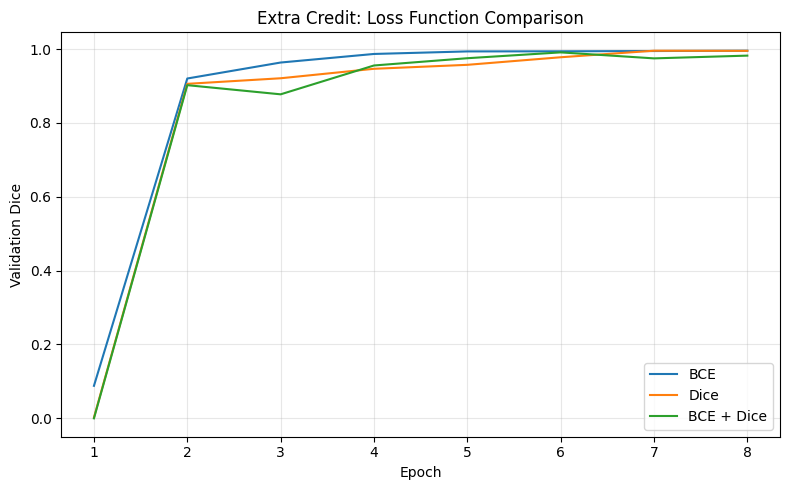

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(bce_history["val_dice"]) + 1
    ),
    bce_history["val_dice"],
    label="BCE"
)

plt.plot(
    range(
        1,
        len(dice_history["val_dice"]) + 1
    ),
    dice_history["val_dice"],
    label="Dice"
)

plt.plot(
    range(
        1,
        len(combo_history["val_dice"]) + 1
    ),
    combo_history["val_dice"],
    label="BCE + Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Dice")

plt.title(
    "Extra Credit: Loss Function Comparison"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "extra_credit_loss_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
loss_ablation_df.to_csv(
    "extra_credit_loss_ablation.csv",
    index=False
)

print(
    "Saved: extra_credit_loss_ablation.csv"
)

Saved: extra_credit_loss_ablation.csv


In [65]:
import json

task3_summary = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,

    "loss_function": "BCE + Dice",

    "mean_validation_dice":
        float(final_val_dice),

    "mean_validation_iou":
        float(final_val_iou),

    "mean_otsu_dice":
        float(
            comparison_metrics[
                "dice_otsu"
            ].mean()
        ),

    "mean_otsu_iou":
        float(
            comparison_metrics[
                "iou_otsu"
            ].mean()
        ),

    "mean_dice_improvement":
        float(
            comparison_metrics[
                "dice_improvement"
            ].mean()
        ),

    "best_loss_extra_credit":
        str(
            best_loss_row["Loss"]
        ),

    "best_loss_validation_dice":
        float(
            best_loss_row[
                "Best_Validation_Dice"
            ]
        )
}

print(
    json.dumps(
        task3_summary,
        indent=4
    )
)

{
    "epochs": 15,
    "batch_size": 4,
    "learning_rate": 0.001,
    "loss_function": "BCE + Dice",
    "mean_validation_dice": 0.9960419535636902,
    "mean_validation_iou": 0.9921171188354492,
    "mean_otsu_dice": 0.978204359061085,
    "mean_otsu_iou": 0.9573514407221039,
    "mean_dice_improvement": 0.01783759748283729,
    "best_loss_extra_credit": "BCE",
    "best_loss_validation_dice": 0.9953645586967468
}


In [66]:
with open(
    "task3_summary.json",
    "w"
) as f:

    json.dump(
        task3_summary,
        f,
        indent=4
    )

print("Saved: task3_summary.json")

Saved: task3_summary.json


In [67]:
from skimage import io, measure, morphology
from skimage.measure import regionprops_table

In [68]:
print("Model loaded:", isinstance(model, torch.nn.Module))
print("Device:", device)

print("Number of test images:", len(test_image_paths))

print("Test image directory:", TEST_IMG_DIR)

Model loaded: True
Device: cpu
Number of test images: 12
Test image directory: assignment_dataset\nuclei_dataset\test\images


In [69]:
def predict_unet_mask(
    model,
    image,
    device,
    threshold=0.5
):

    image_tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        logits = model(image_tensor)

        probability = torch.sigmoid(logits)

        prediction = (
            probability > threshold
        ).float()

    pred_mask = (
        prediction
        .squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )

    probability_map = (
        probability
        .squeeze()
        .cpu()
        .numpy()
    )

    return pred_mask, probability_map

In [70]:
test_example_path = test_image_paths[0]

test_example = preprocess_image(
    test_example_path
)

test_pred_mask, test_prob_map = (
    predict_unet_mask(
        model,
        test_example,
        device
    )
)

print("Image:", test_example_path.name)
print("Image shape:", test_example.shape)
print("Mask shape:", test_pred_mask.shape)

print(
    "Predicted foreground fraction:",
    test_pred_mask.mean()
)

Image: test_000.png
Image shape: (256, 256)
Mask shape: (256, 256)
Predicted foreground fraction: 0.0234222412109375


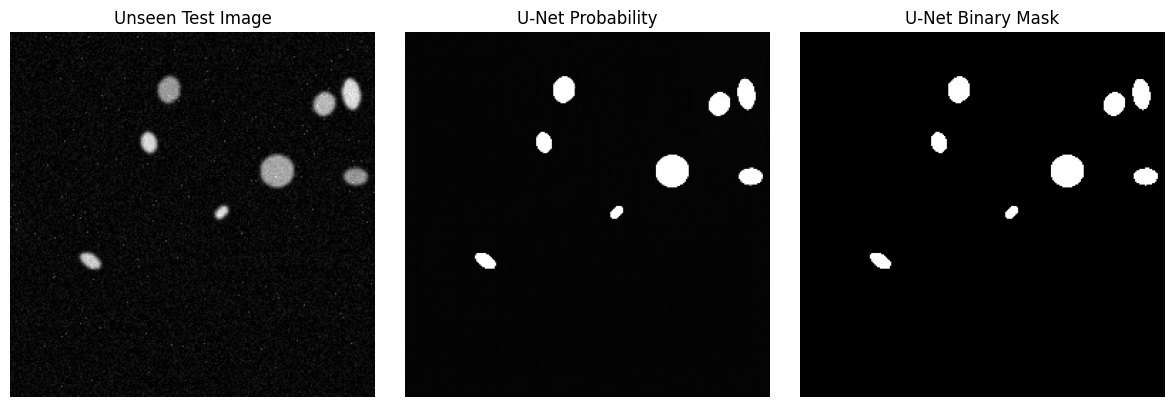

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)

plt.imshow(
    test_example,
    cmap="gray"
)

plt.title("Unseen Test Image")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    test_prob_map,
    cmap="gray"
)

plt.title("U-Net Probability")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    test_pred_mask,
    cmap="gray"
)

plt.title("U-Net Binary Mask")
plt.axis("off")


plt.tight_layout()

plt.show()

In [72]:
def clean_unet_mask(
    mask,
    small_object_size=20
):

    cleaned = morphology.remove_small_objects(
        mask.astype(bool),
        max_size=small_object_size - 1
    )

    cleaned = morphology.remove_small_holes(
        cleaned,
        max_size=small_object_size - 1
    )

    cleaned = morphology.opening(
        cleaned,
        morphology.disk(1)
    )

    cleaned = morphology.closing(
        cleaned,
        morphology.disk(1)
    )

    return cleaned

In [74]:
def clean_unet_mask(mask, small_object_size=20):

    mask = mask.astype(bool)

    # Works with both older and newer scikit-image versions
    try:
        cleaned = morphology.remove_small_objects(
            mask,
            max_size=small_object_size - 1
        )
    except TypeError:
        cleaned = morphology.remove_small_objects(
            mask,
            min_size=small_object_size
        )

    try:
        cleaned = morphology.remove_small_holes(
            cleaned,
            max_size=small_object_size - 1
        )
    except TypeError:
        cleaned = morphology.remove_small_holes(
            cleaned,
            area_threshold=small_object_size
        )

    # Current-compatible morphology operations
    cleaned = morphology.opening(
        cleaned,
        morphology.disk(1)
    )

    cleaned = morphology.closing(
        cleaned,
        morphology.disk(1)
    )

    return cleaned


print("clean_unet_mask function loaded successfully.")

clean_unet_mask function loaded successfully.


In [75]:
test_clean_mask = clean_unet_mask(
    test_pred_mask
)

print(
    "Foreground before cleanup:",
    test_pred_mask.sum()
)

print(
    "Foreground after cleanup:",
    test_clean_mask.sum()
)

Foreground before cleanup: 1535
Foreground after cleanup: 1534


In [76]:
test_labels = measure.label(
    test_clean_mask
)

print(
    "Detected objects:",
    test_labels.max()
)

Detected objects: 8


In [77]:
REGION_PROPERTIES = [
    "label",
    "area",
    "eccentricity",
    "solidity",
    "mean_intensity",
    "major_axis_length",
    "minor_axis_length",
    "equivalent_diameter_area",
    "perimeter"
]

In [78]:
def extract_unet_region_features(
    image,
    mask
):

    labels = measure.label(mask)

    properties = regionprops_table(
        labels,
        intensity_image=image,
        properties=REGION_PROPERTIES
    )

    feature_df = pd.DataFrame(
        properties
    )

    return labels, feature_df

In [79]:
test_labels, test_feature_df = (
    extract_unet_region_features(
        test_example,
        test_clean_mask
    )
)

display(test_feature_df.head())

print(
    "Number of regions:",
    len(test_feature_df)
)

,label,area,eccentricity,solidity,mean_intensity,major_axis_length,minor_axis_length,equivalent_diameter_area,perimeter
0,1,228.0,0.572330,0.974359,0.191260,18.817191,15.430533,17.038152,53.455844
1,2,214.0,0.817060,0.946903,0.269964,21.738352,12.533303,16.506764,55.455844
2,3,199.0,0.484120,0.970732,0.223889,17.007447,14.881542,15.917747,49.455844
3,4,129.0,0.671321,0.969925,0.253605,14.869802,11.021008,12.815924,39.798990
4,5,428.0,0.204671,0.972727,0.211100,23.589655,23.090282,23.344090,73.941125


Number of regions: 8


In [80]:
def summarise_region_features(
    image,
    mask,
    feature_df
):

    image_area = (
        image.shape[0]
        * image.shape[1]
    )

    foreground_fraction = (
        mask.sum()
        / image_area
    )

    if len(feature_df) == 0:

        return {
            "n_objects": 0,
            "mean_area": 0.0,
            "median_area": 0.0,
            "std_area": 0.0,
            "mean_eccentricity": 0.0,
            "mean_solidity": 0.0,
            "mean_intensity": 0.0,
            "mean_equivalent_diameter": 0.0,
            "foreground_fraction":
                float(foreground_fraction)
        }

    return {

        "n_objects":
            int(len(feature_df)),

        "mean_area":
            float(
                feature_df["area"].mean()
            ),

        "median_area":
            float(
                feature_df["area"].median()
            ),

        "std_area":
            float(
                feature_df["area"].std()
            ),

        "mean_eccentricity":
            float(
                feature_df[
                    "eccentricity"
                ].mean()
            ),

        "mean_solidity":
            float(
                feature_df[
                    "solidity"
                ].mean()
            ),

        "mean_intensity":
            float(
                feature_df[
                    "mean_intensity"
                ].mean()
            ),

        "mean_equivalent_diameter":
            float(
                feature_df[
                    "equivalent_diameter_area"
                ].mean()
            ),

        "foreground_fraction":
            float(
                foreground_fraction
            )
    }

In [81]:
test_summary = summarise_region_features(
    test_example,
    test_clean_mask,
    test_feature_df
)

print(
    json.dumps(
        test_summary,
        indent=4
    )
)

{
    "n_objects": 8,
    "mean_area": 191.75,
    "median_area": 180.0,
    "std_area": 110.78905309512437,
    "mean_eccentricity": 0.6349620727053291,
    "mean_solidity": 0.9668403366986098,
    "mean_intensity": 0.2269163317978382,
    "mean_equivalent_diameter": 15.095057918380329,
    "foreground_fraction": 0.023406982421875
}


In [82]:
def classify_density(
    n_objects,
    foreground_fraction
):

    if (
        n_objects < 20
        and foreground_fraction < 0.10
    ):
        return "low"

    elif (
        n_objects < 50
        and foreground_fraction < 0.25
    ):
        return "moderate"

    else:
        return "high"

In [83]:
def classify_shape_regularity(
    mean_solidity,
    mean_eccentricity
):

    if (
        mean_solidity >= 0.90
        and mean_eccentricity <= 0.65
    ):
        return "regular"

    elif mean_solidity >= 0.80:
        return "moderately_regular"

    else:
        return "irregular"

In [84]:
def determine_quality_flag(
    n_objects,
    foreground_fraction,
    mean_solidity
):

    if n_objects == 0:
        return "poor"

    if (
        foreground_fraction < 0.01
        or foreground_fraction > 0.60
    ):
        return "poor"

    if mean_solidity < 0.70:
        return "moderate"

    return "good"

In [85]:
def build_source_record(
    image_id,
    summary
):

    density_class = classify_density(
        summary["n_objects"],
        summary["foreground_fraction"]
    )

    shape_regularity = (
        classify_shape_regularity(
            summary["mean_solidity"],
            summary[
                "mean_eccentricity"
            ]
        )
    )

    quality_flag = (
        determine_quality_flag(
            summary["n_objects"],
            summary[
                "foreground_fraction"
            ],
            summary[
                "mean_solidity"
            ]
        )
    )

    record = {

        "image_id":
            image_id,

        "n_objects":
            summary["n_objects"],

        "mean_area":
            round(
                summary["mean_area"],
                3
            ),

        "density_class":
            density_class,

        "quality_flag":
            quality_flag,

        "shape_regularity":
            shape_regularity,

        "mean_eccentricity":
            round(
                summary[
                    "mean_eccentricity"
                ],
                4
            ),

        "mean_solidity":
            round(
                summary[
                    "mean_solidity"
                ],
                4
            ),

        "mean_intensity":
            round(
                summary[
                    "mean_intensity"
                ],
                4
            ),

        "foreground_fraction":
            round(
                summary[
                    "foreground_fraction"
                ],
                4
            )
    }

    return record

In [86]:
test_source_record = (
    build_source_record(
        test_example_path.name,
        test_summary
    )
)

print(
    json.dumps(
        test_source_record,
        indent=4
    )
)

{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "shape_regularity": "regular",
    "mean_eccentricity": 0.635,
    "mean_solidity": 0.9668,
    "mean_intensity": 0.2269,
    "foreground_fraction": 0.0234
}


In [87]:
def build_hybrid_prompt(
    source_record
):

    prompt = f"""
You are a data-analysis assistant describing quantitative
microscopy segmentation results.

You have NOT been given the original image.
You have only been given measurements produced by a U-Net
segmentation model and deterministic Python feature extraction.

SOURCE-OF-TRUTH RECORD
{json.dumps(source_record, indent=4)}

TASK

Return valid JSON only using exactly this structure:

{{
    "image_id": "{source_record['image_id']}",
    "n_objects": {source_record['n_objects']},
    "mean_area": {source_record['mean_area']},
    "density_class": "{source_record['density_class']}",
    "quality_flag": "{source_record['quality_flag']}",
    "narrative": "one concise paragraph interpreting only the supplied measurements"
}}

STRICT RULES

1. Do not change image_id.
2. Do not change n_objects.
3. Do not change mean_area.
4. Do not change density_class.
5. Do not change quality_flag.
6. Do not invent tissue type, diagnosis, organ, stain, species,
   disease, or acquisition method.
7. The narrative must describe only the supplied quantitative evidence.
8. If the measurements are insufficient for a biological conclusion,
   say that such a conclusion cannot be determined.
9. Do not include Markdown.
10. Do not include text outside the JSON object.
"""

    return prompt

In [88]:
test_hybrid_prompt = (
    build_hybrid_prompt(
        test_source_record
    )
)

print(test_hybrid_prompt)


You are a data-analysis assistant describing quantitative
microscopy segmentation results.

You have NOT been given the original image.
You have only been given measurements produced by a U-Net
segmentation model and deterministic Python feature extraction.

SOURCE-OF-TRUTH RECORD
{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "shape_regularity": "regular",
    "mean_eccentricity": 0.635,
    "mean_solidity": 0.9668,
    "mean_intensity": 0.2269,
    "foreground_fraction": 0.0234
}

TASK

Return valid JSON only using exactly this structure:

{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "narrative": "one concise paragraph interpreting only the supplied measurements"
}

STRICT RULES

1. Do not change image_id.
2. Do not change n_objects.
3. Do not change mean_area.
4. Do not change density_class.
5. Do n

In [91]:
import requests

TEXT_MODEL = "llama3.2:latest"
OLLAMA_CHAT_URL = "http://localhost:11434/api/chat"

def query_text_llm(
    prompt,
    model=TEXT_MODEL,
    temperature=0.1
):
    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "stream": False,
        "options": {
            "temperature": temperature
        }
    }

    response = requests.post(
        OLLAMA_CHAT_URL,
        json=payload,
        timeout=300
    )

    if response.status_code != 200:
        print("Ollama status:", response.status_code)
        print(response.text)
        response.raise_for_status()

    result = response.json()

    return result["message"]["content"]


print("query_text_llm() loaded successfully.")

query_text_llm() loaded successfully.


In [92]:
test_llm_response = query_text_llm(
    test_hybrid_prompt
)

print("HYBRID LLM RESPONSE")
print("-------------------")

print(test_llm_response)

HYBRID LLM RESPONSE
-------------------
{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "narrative": "The image contains 8 objects with a mean area of 191.75 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation."
}


In [93]:
try:

    test_llm_json = json.loads(
        test_llm_response
    )

    print("Valid JSON ✓")

    print(
        json.dumps(
            test_llm_json,
            indent=4
        )
    )

except json.JSONDecodeError as e:

    print("Invalid JSON ✗")

    print(e)

    test_llm_json = None

Valid JSON ✓
{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "narrative": "The image contains 8 objects with a mean area of 191.75 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation."
}


In [94]:
def validate_llm_record(
    llm_record,
    source_record
):

    checks = {

        "image_id":
            llm_record.get(
                "image_id"
            )
            ==
            source_record[
                "image_id"
            ],

        "n_objects":
            llm_record.get(
                "n_objects"
            )
            ==
            source_record[
                "n_objects"
            ],

        "mean_area":
            float(
                llm_record.get(
                    "mean_area",
                    -1
                )
            )
            ==
            float(
                source_record[
                    "mean_area"
                ]
            ),

        "density_class":
            llm_record.get(
                "density_class"
            )
            ==
            source_record[
                "density_class"
            ],

        "quality_flag":
            llm_record.get(
                "quality_flag"
            )
            ==
            source_record[
                "quality_flag"
            ]
    }

    return checks

In [96]:
if test_llm_json is not None:

    validation_checks = (
        validate_llm_record(
            test_llm_json,
            test_source_record
        )
    )

    for key, passed in (
        validation_checks.items()
    ):

        symbol = (
            "T"
            if passed
            else "F"
        )

        print(
            f"{symbol} {key}: {passed}"
        )

T image_id: True
T n_objects: True
T mean_area: True
T density_class: True
T quality_flag: True


In [97]:
def create_fallback_narrative(
    source_record
):

    return (
        f"The U-Net segmentation produced "
        f"{source_record['n_objects']} connected objects "
        f"with a mean area of "
        f"{source_record['mean_area']:.2f} pixels. "
        f"The deterministic density classification was "
        f"{source_record['density_class']}, while the "
        f"shape pattern was classified as "
        f"{source_record['shape_regularity']}. "
        f"The segmentation quality flag was "
        f"{source_record['quality_flag']}. "
        f"No tissue type, diagnosis, or biological identity "
        f"can be determined from these measurements alone."
    )

In [98]:
def get_hybrid_llm_record(
    source_record
):

    prompt = build_hybrid_prompt(
        source_record
    )

    raw_response = query_text_llm(
        prompt
    )

    try:

        parsed = json.loads(
            raw_response
        )

    except json.JSONDecodeError:

        parsed = None

    if parsed is not None:

        checks = validate_llm_record(
            parsed,
            source_record
        )

        if all(checks.values()):

            return (
                parsed,
                raw_response,
                True
            )

    # deterministic fallback
    fallback = {

        "image_id":
            source_record["image_id"],

        "n_objects":
            source_record["n_objects"],

        "mean_area":
            source_record["mean_area"],

        "density_class":
            source_record[
                "density_class"
            ],

        "quality_flag":
            source_record[
                "quality_flag"
            ],

        "narrative":
            create_fallback_narrative(
                source_record
            )
    }

    return (
        fallback,
        raw_response,
        False
    )

In [100]:
def run_hybrid_pipeline_single(
    image_path,
    model,
    device
):

    # 1. Preprocess image
    image = preprocess_image(
        image_path
    )

    # 2. U-Net prediction
    raw_mask, probability = (
        predict_unet_mask(
            model,
            image,
            device
        )
    )

    # 3. Clean mask
    clean_mask = (
        clean_unet_mask(
            raw_mask
        )
    )

    # 4. Region features
    labels, feature_df = (
        extract_unet_region_features(
            image,
            clean_mask
        )
    )

    # 5. Numerical summary
    summary = (
        summarise_region_features(
            image,
            clean_mask,
            feature_df
        )
    )

    # 6. Deterministic record
    source_record = (
        build_source_record(
            image_path.name,
            summary
        )
    )

    # 7. LLM narrative
    llm_record, raw_llm, valid = (
        get_hybrid_llm_record(
            source_record
        )
    )

    return {

        "image":
            image,

        "probability":
            probability,

        "mask":
            clean_mask,

        "labels":
            labels,

        "features":
            feature_df,

        "source_record":
            source_record,

        "llm_record":
            llm_record,

        "raw_llm_response":
            raw_llm,

        "llm_validation_passed":
            valid
    }

In [101]:
single_result = (
    run_hybrid_pipeline_single(
        test_image_paths[0],
        model,
        device
    )
)

print(
    json.dumps(
        single_result[
            "llm_record"
        ],
        indent=4
    )
)

print(
    "\nLLM validation passed:",
    single_result[
        "llm_validation_passed"
    ]
)

{
    "image_id": "test_000.png",
    "n_objects": 8,
    "mean_area": 191.75,
    "density_class": "low",
    "quality_flag": "good",
    "narrative": "The image contains 8 objects with a mean area of 191.75 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation."
}

LLM validation passed: True


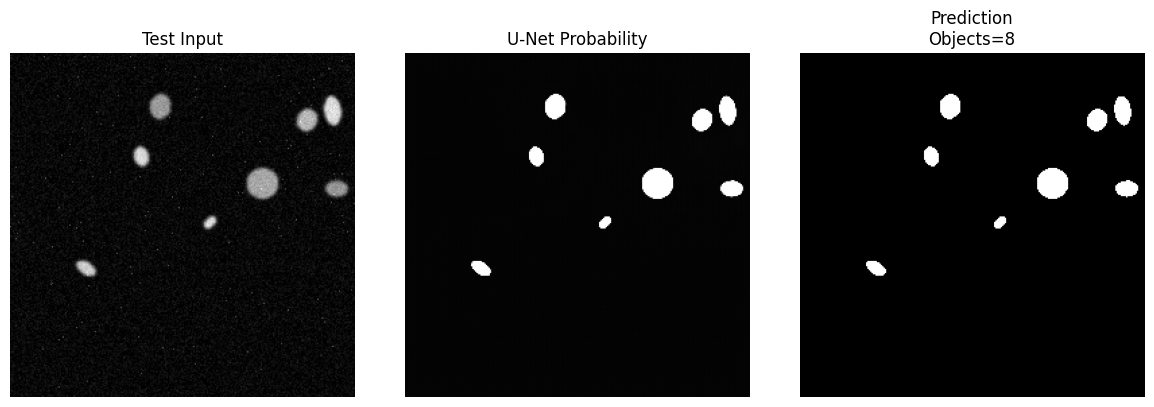

In [102]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)

plt.imshow(
    single_result["image"],
    cmap="gray"
)

plt.title("Test Input")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    single_result[
        "probability"
    ],
    cmap="gray"
)

plt.title("U-Net Probability")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    single_result["mask"],
    cmap="gray"
)

plt.title(
    f"Prediction\n"
    f"Objects="
    f"{single_result['source_record']['n_objects']}"
)

plt.axis("off")


plt.tight_layout()

plt.savefig(
    "task4_example_pipeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
all_test_results = []

all_test_feature_tables = {}

for i, image_path in enumerate(
    test_image_paths
):

    print(
        f"Processing "
        f"{i + 1}/{len(test_image_paths)}: "
        f"{image_path.name}"
    )

    result = (
        run_hybrid_pipeline_single(
            image_path,
            model,
            device
        )
    )

    all_test_results.append(
        result
    )

    all_test_feature_tables[
        image_path.name
    ] = result["features"]

print("Finished all test images.")

Processing 1/12: test_000.png
Processing 2/12: test_001.png
Processing 3/12: test_002.png
Processing 4/12: test_003.png
Processing 5/12: test_004.png
Processing 6/12: test_005.png
Processing 7/12: test_006.png
Processing 8/12: test_007.png
Processing 9/12: test_008.png
Processing 10/12: test_009.png
Processing 11/12: test_010.png
Processing 12/12: test_011.png
Finished all test images.


In [104]:
hybrid_json_records = [
    result["llm_record"]
    for result
    in all_test_results
]

print(
    json.dumps(
        hybrid_json_records[:3],
        indent=4
    )
)

[
    {
        "image_id": "test_000.png",
        "n_objects": 8,
        "mean_area": 191.75,
        "density_class": "low",
        "quality_flag": "good",
        "narrative": "The image contains 8 objects with a mean area of 191.75 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation."
    },
    {
        "image_id": "test_001.png",
        "n_objects": 14,
        "mean_area": 200.857,
        "density_class": "low",
        "quality_flag": "good",
        "narrative": "The image contains 14 objects with a mean area of 200.857 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated objects. The quality flag indicates that the image is in good condition. These quantitative measuremen

In [105]:
with open(
    "task4_hybrid_records.json",
    "w"
) as f:

    json.dump(
        hybrid_json_records,
        f,
        indent=4
    )

print(
    "Saved: task4_hybrid_records.json"
)

Saved: task4_hybrid_records.json


In [106]:
hybrid_df = pd.DataFrame(
    hybrid_json_records
)

display(hybrid_df)

,image_id,n_objects,mean_area,density_class,quality_flag,narrative
0,test_000.png,8,191.750,low,good,The image contains 8 objects with a mean area ...
1,test_001.png,14,200.857,low,good,The image contains 14 objects with a mean area...
2,test_002.png,25,228.920,moderate,good,The image contains 25 objects with a mean area...
3,test_003.png,19,204.632,low,good,The image contains 19 objects with a mean area...
4,test_004.png,41,346.634,moderate,good,The image contains 41 objects with a mean area...
5,test_005.png,14,467.429,low,good,The image contains 14 objects with a mean area...
6,test_006.png,8,200.000,low,good,The image contains 8 objects with a mean area ...
7,test_007.png,23,205.609,moderate,good,The image contains 23 objects with a mean area...
8,test_008.png,22,250.682,moderate,good,The image contains 22 objects with a mean area...
9,test_009.png,21,178.952,moderate,good,The image contains 21 objects with a mean area...


In [107]:
hybrid_df.to_csv(
    "task4_test_results.csv",
    index=False
)

print(
    "Saved: task4_test_results.csv"
)

Saved: task4_test_results.csv


In [108]:
source_records = [
    result["source_record"]
    for result
    in all_test_results
]

source_df = pd.DataFrame(
    source_records
)

display(source_df)

,image_id,n_objects,mean_area,density_class,quality_flag,shape_regularity,mean_eccentricity,mean_solidity,mean_intensity,foreground_fraction
0,test_000.png,8,191.750,low,good,regular,0.6350,0.9668,0.2269,0.0234
1,test_001.png,14,200.857,low,good,regular,0.6279,0.9517,0.2338,0.0429
2,test_002.png,25,228.920,moderate,good,moderately_regular,0.6803,0.9430,0.2409,0.0873
3,test_003.png,19,204.632,low,good,moderately_regular,0.6976,0.9633,0.2544,0.0593
4,test_004.png,41,346.634,moderate,good,moderately_regular,0.6568,0.9230,0.2528,0.2169
5,test_005.png,14,467.429,low,good,regular,0.6440,0.9246,0.2493,0.0999
6,test_006.png,8,200.000,low,good,regular,0.6105,0.9674,0.2706,0.0244
7,test_007.png,23,205.609,moderate,good,regular,0.6496,0.9485,0.2476,0.0722
8,test_008.png,22,250.682,moderate,good,regular,0.6170,0.9416,0.2461,0.0842
9,test_009.png,21,178.952,moderate,good,regular,0.6165,0.9643,0.2391,0.0573


In [109]:
source_df.to_csv(
    "task4_source_measurements.csv",
    index=False
)

print(
    "Saved: task4_source_measurements.csv"
)

Saved: task4_source_measurements.csv


In [110]:
validation_summary = []

for result in all_test_results:

    validation_summary.append({

        "image_id":
            result[
                "source_record"
            ]["image_id"],

        "llm_validation_passed":
            result[
                "llm_validation_passed"
            ]
    })

validation_df = pd.DataFrame(
    validation_summary
)

display(validation_df)

,image_id,llm_validation_passed
0,test_000.png,True
1,test_001.png,True
2,test_002.png,True
3,test_003.png,True
4,test_004.png,True
5,test_005.png,True
6,test_006.png,True
7,test_007.png,True
8,test_008.png,True
9,test_009.png,True


In [111]:
pass_rate = (
    validation_df[
        "llm_validation_passed"
    ].mean()
)

print(
    f"LLM structured-output validation "
    f"pass rate: {pass_rate:.1%}"
)

LLM structured-output validation pass rate: 100.0%


In [112]:
print(
    "Number of test images:",
    len(hybrid_df)
)

print(
    "Mean detected objects:",
    hybrid_df[
        "n_objects"
    ].mean()
)

print(
    "Mean object area:",
    hybrid_df[
        "mean_area"
    ].mean()
)

print(
    "\nDensity classes:"
)

print(
    hybrid_df[
        "density_class"
    ].value_counts()
)

print(
    "\nQuality flags:"
)

print(
    hybrid_df[
        "quality_flag"
    ].value_counts()
)

Number of test images: 12
Mean detected objects: 20.666666666666668
Mean object area: 254.8261666666667

Density classes:
density_class
low         6
moderate    6
Name: count, dtype: int64

Quality flags:
quality_flag
good    12
Name: count, dtype: int64


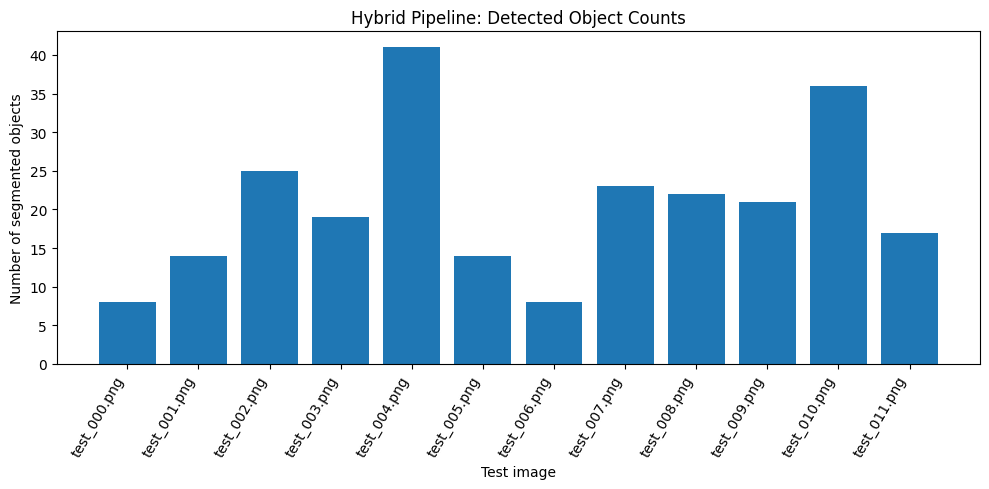

In [113]:
plt.figure(figsize=(10, 5))

plt.bar(
    hybrid_df["image_id"],
    hybrid_df["n_objects"]
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel(
    "Number of segmented objects"
)

plt.xlabel(
    "Test image"
)

plt.title(
    "Hybrid Pipeline: Detected Object Counts"
)

plt.tight_layout()

plt.savefig(
    "task4_test_object_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
os.makedirs(
    "task4_feature_tables",
    exist_ok=True
)

for image_id, df in (
    all_test_feature_tables.items()
):

    filename = (
        image_id
        .replace(".png", "")
        + "_features.csv"
    )

    df.to_csv(
        os.path.join(
            "task4_feature_tables",
            filename
        ),
        index=False
    )

print(
    "Saved individual region feature tables."
)

Saved individual region feature tables.


In [115]:
robustness_path = test_image_paths[0]

clean_image = preprocess_image(
    robustness_path
)

print(
    "Robustness image:",
    robustness_path.name
)

Robustness image: test_000.png


In [117]:
from skimage.filters import gaussian

def apply_heavy_blur(
    image,
    sigma=4
):

    return gaussian(
        image,
        sigma=sigma,
        preserve_range=True
    )

In [118]:
blurred_image = apply_heavy_blur(
    clean_image,
    sigma=4
)

In [119]:
clean_mask_raw, clean_prob = (
    predict_unet_mask(
        model,
        clean_image,
        device
    )
)

blur_mask_raw, blur_prob = (
    predict_unet_mask(
        model,
        blurred_image,
        device
    )
)

clean_mask_rob = (
    clean_unet_mask(
        clean_mask_raw
    )
)

blur_mask_rob = (
    clean_unet_mask(
        blur_mask_raw
    )
)

In [121]:
import numpy as np

def dice_score(pred, target, smooth=1e-8):
    pred = np.asarray(pred).astype(bool)
    target = np.asarray(target).astype(bool)

    intersection = np.logical_and(pred, target).sum()

    return (
        2 * intersection + smooth
    ) / (
        pred.sum()
        + target.sum()
        + smooth
    )


def iou_score(pred, target, smooth=1e-8):
    pred = np.asarray(pred).astype(bool)
    target = np.asarray(target).astype(bool)

    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


print("dice_score() and iou_score() loaded successfully.")

dice_score() and iou_score() loaded successfully.


In [122]:
mask_dice_corruption = dice_score(
    clean_mask_rob,
    blur_mask_rob
)

mask_iou_corruption = iou_score(
    clean_mask_rob,
    blur_mask_rob
)

print(
    f"Clean-vs-blurred mask Dice: "
    f"{mask_dice_corruption:.4f}"
)

print(
    f"Clean-vs-blurred mask IoU: "
    f"{mask_iou_corruption:.4f}"
)

Clean-vs-blurred mask Dice: 0.7110
Clean-vs-blurred mask IoU: 0.5516


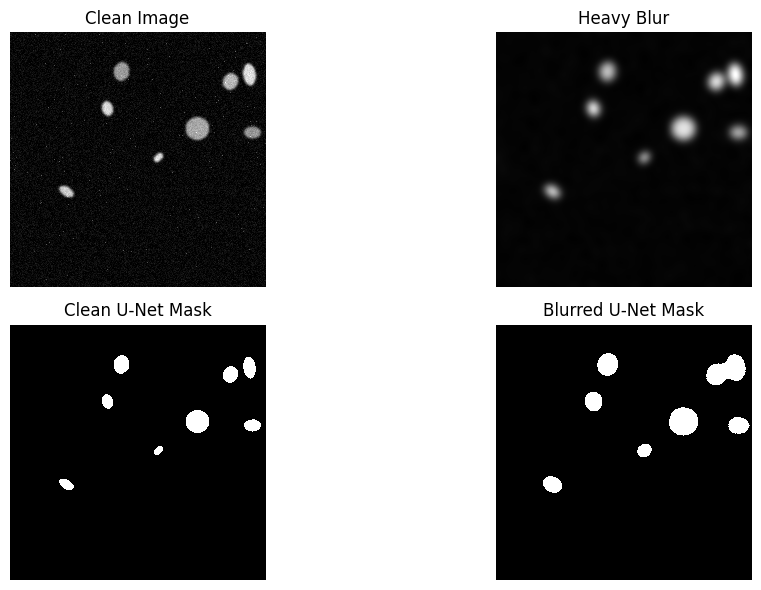

In [123]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)

plt.imshow(
    clean_image,
    cmap="gray"
)

plt.title("Clean Image")
plt.axis("off")


plt.subplot(2, 2, 2)

plt.imshow(
    blurred_image,
    cmap="gray"
)

plt.title("Heavy Blur")
plt.axis("off")


plt.subplot(2, 2, 3)

plt.imshow(
    clean_mask_rob,
    cmap="gray"
)

plt.title("Clean U-Net Mask")
plt.axis("off")


plt.subplot(2, 2, 4)

plt.imshow(
    blur_mask_rob,
    cmap="gray"
)

plt.title("Blurred U-Net Mask")
plt.axis("off")


plt.tight_layout()

plt.savefig(
    "extra_credit_robustness_masks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
clean_labels_rob, clean_features_rob = (
    extract_unet_region_features(
        clean_image,
        clean_mask_rob
    )
)

blur_labels_rob, blur_features_rob = (
    extract_unet_region_features(
        blurred_image,
        blur_mask_rob
    )
)

In [125]:
clean_summary_rob = (
    summarise_region_features(
        clean_image,
        clean_mask_rob,
        clean_features_rob
    )
)

blur_summary_rob = (
    summarise_region_features(
        blurred_image,
        blur_mask_rob,
        blur_features_rob
    )
)

In [126]:
robustness_features_df = pd.DataFrame({
    "Feature": [
        "n_objects",
        "mean_area",
        "mean_eccentricity",
        "mean_solidity",
        "mean_intensity",
        "foreground_fraction"
    ],

    "Clean": [
        clean_summary_rob[
            "n_objects"
        ],

        clean_summary_rob[
            "mean_area"
        ],

        clean_summary_rob[
            "mean_eccentricity"
        ],

        clean_summary_rob[
            "mean_solidity"
        ],

        clean_summary_rob[
            "mean_intensity"
        ],

        clean_summary_rob[
            "foreground_fraction"
        ]
    ],

    "Blurred": [
        blur_summary_rob[
            "n_objects"
        ],

        blur_summary_rob[
            "mean_area"
        ],

        blur_summary_rob[
            "mean_eccentricity"
        ],

        blur_summary_rob[
            "mean_solidity"
        ],

        blur_summary_rob[
            "mean_intensity"
        ],

        blur_summary_rob[
            "foreground_fraction"
        ]
    ]
})

robustness_features_df[
    "Absolute_Difference"
] = abs(
    robustness_features_df[
        "Clean"
    ]
    -
    robustness_features_df[
        "Blurred"
    ]
)

display(
    robustness_features_df
)

,Feature,Clean,Blurred,Absolute_Difference
0,n_objects,8.000000,7.000000,1.000000
1,mean_area,191.750000,397.285714,205.535714
2,mean_eccentricity,0.634962,0.534427,0.100535
3,mean_solidity,0.966840,0.954054,0.012786
4,mean_intensity,0.226916,0.111883,0.115033
5,foreground_fraction,0.023407,0.042435,0.019028


In [127]:
robustness_features_df = pd.DataFrame({
    "Feature": [
        "n_objects",
        "mean_area",
        "mean_eccentricity",
        "mean_solidity",
        "mean_intensity",
        "foreground_fraction"
    ],

    "Clean": [
        clean_summary_rob[
            "n_objects"
        ],

        clean_summary_rob[
            "mean_area"
        ],

        clean_summary_rob[
            "mean_eccentricity"
        ],

        clean_summary_rob[
            "mean_solidity"
        ],

        clean_summary_rob[
            "mean_intensity"
        ],

        clean_summary_rob[
            "foreground_fraction"
        ]
    ],

    "Blurred": [
        blur_summary_rob[
            "n_objects"
        ],

        blur_summary_rob[
            "mean_area"
        ],

        blur_summary_rob[
            "mean_eccentricity"
        ],

        blur_summary_rob[
            "mean_solidity"
        ],

        blur_summary_rob[
            "mean_intensity"
        ],

        blur_summary_rob[
            "foreground_fraction"
        ]
    ]
})

robustness_features_df[
    "Absolute_Difference"
] = abs(
    robustness_features_df[
        "Clean"
    ]
    -
    robustness_features_df[
        "Blurred"
    ]
)

display(
    robustness_features_df
)

,Feature,Clean,Blurred,Absolute_Difference
0,n_objects,8.000000,7.000000,1.000000
1,mean_area,191.750000,397.285714,205.535714
2,mean_eccentricity,0.634962,0.534427,0.100535
3,mean_solidity,0.966840,0.954054,0.012786
4,mean_intensity,0.226916,0.111883,0.115033
5,foreground_fraction,0.023407,0.042435,0.019028


In [129]:
clean_record_rob = (
    build_source_record(
        robustness_path.name
        + "_clean",
        clean_summary_rob
    )
)

blur_record_rob = (
    build_source_record(
        robustness_path.name
        + "_blurred",
        blur_summary_rob
    )
)

In [131]:
clean_llm_rob, _, clean_valid_rob = (
    get_hybrid_llm_record(
        clean_record_rob
    )
)

blur_llm_rob, _, blur_valid_rob = (
    get_hybrid_llm_record(
        blur_record_rob
    )
)

In [132]:
print("=" * 70)
print("CLEAN NARRATIVE")
print("=" * 70)

print(
    clean_llm_rob[
        "narrative"
    ]
)


print(
    "\n" + "=" * 70
)

print("BLURRED NARRATIVE")
print("=" * 70)

print(
    blur_llm_rob[
        "narrative"
    ]
)

CLEAN NARRATIVE
The image contains 8 objects with a mean area of 191.75 square units, indicating relatively small structures. The density class is classified as low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation.

BLURRED NARRATIVE
The image contains 7 objects with a mean area of 397.286 square units, indicating relatively small structures. The density class is low, suggesting sparse or isolated features. The quality flag indicates that the image is in good condition. These quantitative measurements provide limited evidence for biological interpretation.


In [133]:
robustness_features_df.to_csv(
    "extra_credit_robustness_features.csv",
    index=False
)

robustness_results = {

    "image":
        robustness_path.name,

    "corruption":
        "heavy_blur_sigma_4",

    "mask_dice_clean_vs_corrupt":
        float(
            mask_dice_corruption
        ),

    "mask_iou_clean_vs_corrupt":
        float(
            mask_iou_corruption
        ),

    "clean_record":
        clean_record_rob,

    "corrupted_record":
        blur_record_rob,

    "clean_narrative":
        clean_llm_rob[
            "narrative"
        ],

    "corrupted_narrative":
        blur_llm_rob[
            "narrative"
        ]
}

with open(
    "extra_credit_robustness.json",
    "w"
) as f:

    json.dump(
        robustness_results,
        f,
        indent=4
    )

print(
    "Saved robustness results."
)

Saved robustness results.


In [134]:
feature_change_detected = (
    robustness_features_df[
        "Absolute_Difference"
    ].sum() > 0
)

mask_change_detected = (
    mask_dice_corruption < 0.999
)

narrative_change_detected = (
    clean_llm_rob[
        "narrative"
    ]
    !=
    blur_llm_rob[
        "narrative"
    ]
)

print(
    "Mask change detected:",
    mask_change_detected
)

print(
    "Feature change detected:",
    feature_change_detected
)

print(
    "Narrative change detected:",
    narrative_change_detected
)

Mask change detected: True
Feature change detected: True
Narrative change detected: True


In [135]:
task4_summary = {

    "n_test_images":
        int(len(hybrid_df)),

    "mean_n_objects":
        float(
            hybrid_df[
                "n_objects"
            ].mean()
        ),

    "mean_area":
        float(
            hybrid_df[
                "mean_area"
            ].mean()
        ),

    "llm_validation_pass_rate":
        float(pass_rate),

    "density_counts":
        hybrid_df[
            "density_class"
        ].value_counts().to_dict(),

    "quality_counts":
        hybrid_df[
            "quality_flag"
        ].value_counts().to_dict(),

    "robustness_mask_dice":
        float(
            mask_dice_corruption
        ),

    "robustness_mask_iou":
        float(
            mask_iou_corruption
        )
}

print(
    json.dumps(
        task4_summary,
        indent=4
    )
)

{
    "n_test_images": 12,
    "mean_n_objects": 20.666666666666668,
    "mean_area": 254.8261666666667,
    "llm_validation_pass_rate": 1.0,
    "density_counts": {
        "low": 6,
        "moderate": 6
    },
    "quality_counts": {
        "good": 12
    },
    "robustness_mask_dice": 0.7110081112405306,
    "robustness_mask_iou": 0.5516001438347659
}


In [136]:
with open(
    "task4_summary.json",
    "w"
) as f:

    json.dump(
        task4_summary,
        f,
        indent=4
    )

print(
    "Saved: task4_summary.json"
)

Saved: task4_summary.json
